In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:

# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1
Ign:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2min 45s (62.7 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf

# 물량확인해보기(넘겨도 됨)

In [ ]:
import pandas as pd
import os


# 파일 경로
input_file = '/content/A0067885_데이터.xlsx'

# 🔹 Google Drive에 저장 경로 설정
output_dir = '/content/drive/MyDrive/태림_결과'
os.makedirs(output_dir, exist_ok=True)

# 데이터 읽기
df = pd.read_excel(input_file)

print("=== 중복 제거 전 ===")
print(f"전체 행 수: {len(df)}")
print(f"FIRM 행 수: {len(df[df['Firm/Forecast'] == 'FIRM'])}")
print(f"FORECAST 행 수: {len(df[df['Firm/Forecast'] == 'FORECAST'])}")

# FIRM / FORECAST 분리
firm_df = df[df['Firm/Forecast'] == 'FIRM'].copy()
forecast_df = df[df['Firm/Forecast'] == 'FORECAST'].copy()

# FIRM 중복 제거
firm_deduped = firm_df.sort_values('ID_Release').groupby(
    ['Year', 'Month', 'Day', 'Quantity'],
    as_index=False
).first()

print("\n=== FIRM 중복 제거 후 ===")
print(f"FIRM 중복 제거 전: {len(firm_df)}개")
print(f"FIRM 중복 제거 후: {len(firm_deduped)}개")
print(f"제거된 FIRM 행: {len(firm_df) - len(firm_deduped)}개")

# 합치기
df_cleaned = pd.concat([forecast_df, firm_deduped], ignore_index=True)

# 정렬
df_cleaned = df_cleaned.sort_values(['ID_Release', 'Year', 'Month', 'Day']).reset_index(drop=True)

print("\n=== 최종 결과 ===")
print(f"최종 행 수: {len(df_cleaned)}")
print(f"FIRM 행 수: {len(df_cleaned[df_cleaned['Firm/Forecast'] == 'FIRM'])}")
print(f"FORECAST 행 수: {len(df_cleaned[df_cleaned['Firm/Forecast'] == 'FORECAST'])}")

# 🔹 저장 (Google Drive)
output_file = f'{output_dir}/A0067885_중복제거.xlsx'
df_cleaned.to_excel(output_file, index=False)

print(f"\n 저장 완료: {output_file}")

# 샘플 확인
print("\n=== 중복 제거 샘플 확인 ===")
sample = df_cleaned[
    (df_cleaned['Year'] == 2025) &
    (df_cleaned['Month'] == 'March') &
    (df_cleaned['Day'] == 4) &
    (df_cleaned['Quantity'] == 2.688) &
    (df_cleaned['Firm/Forecast'] == 'FIRM')
]

print(sample[['ID_Release', 'Year', 'Month', 'Day', 'Quantity', 'Firm/Forecast']].to_string())

=== 중복 제거 전 ===
전체 행 수: 4780
FIRM 행 수: 211
FORECAST 행 수: 4569

=== FIRM 중복 제거 후 ===
FIRM 중복 제거 전: 211개
FIRM 중복 제거 후: 87개
제거된 FIRM 행: 124개

=== 최종 결과 ===
최종 행 수: 4656
FIRM 행 수: 87
FORECAST 행 수: 4569

 저장 완료: /content/drive/MyDrive/태림_결과/A0067885_중복제거.xlsx

=== 중복 제거 샘플 확인 ===
        ID_Release  Year  Month  Day  Quantity Firm/Forecast
2250  20250210-004  2025  March    4     2.688          FIRM


=== 데이터 정보 ===
전체 행 수: 4656
ID_Release 개수: 75
고유 납품일 개수: 483

=== Forecast→Firm 전환 케이스 찾기 ===

전환 케이스 발견: 44개
      delivery_date  year     month  day  forecast_count  firm_count  \
0    2024-August-21  2024    August   21               1           1   
1    2024-August-27  2024    August   27               1           1   
2    2024-August-28  2024    August   28               2           2   
3       2024-July-2  2024      July    2               2           1   
4      2024-July-12  2024      July   12               1           2   
5      2024-June-25  2024      June   25               1           2   
6  2024-November-18  2024  November   18              19           1   
7  2024-November-26  2024  November   26               1           1   
8   2024-October-14  2024   October   14               7           1   
9   2024-October-21  2024   October   21              12           1   

   forecast_qty_min  forecast_qty_max  firm_qty first_forecast_release  \
0             4.368    

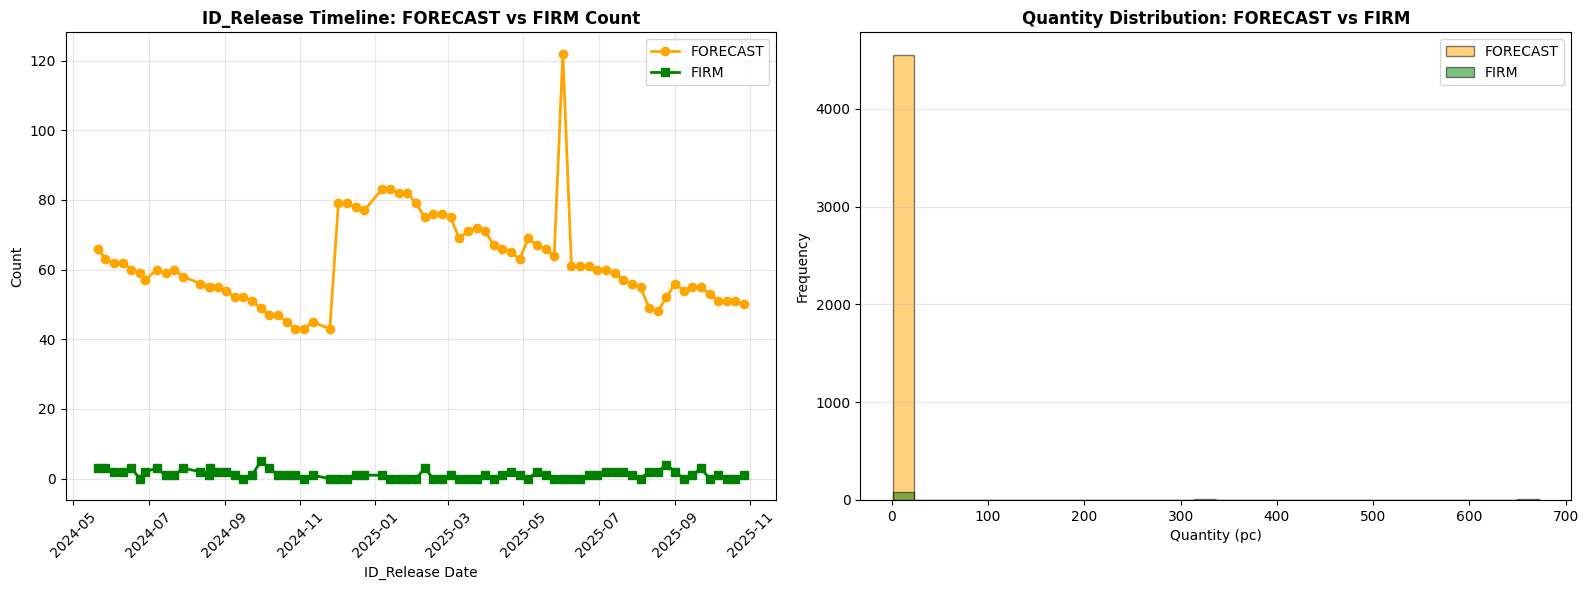

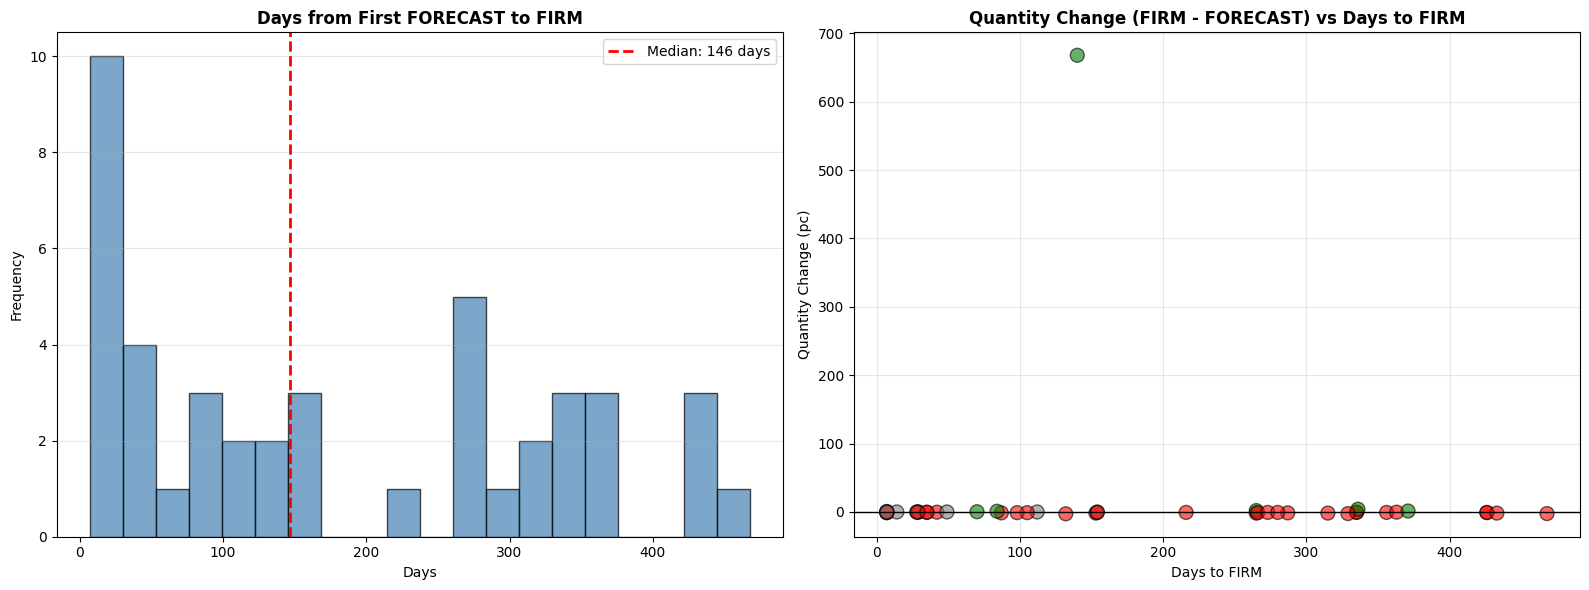

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from datetime import datetime

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 읽기
df = pd.read_excel('/content/A0067885_중복제거.xlsx')

print("=== 데이터 정보 ===")
print(f"전체 행 수: {len(df)}")
print(f"ID_Release 개수: {df['ID_Release'].nunique()}")
print(f"고유 납품일 개수: {df.groupby(['Year', 'Month', 'Day']).ngroups}")

# ID_Release를 날짜 형식으로 변환하여 정렬
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df = df.sort_values('Release_Date')

# 특정 납품일의 Forecast→Firm 패턴 분석
print("\n=== Forecast→Firm 전환 케이스 찾기 ===")

# 각 납품일별로 그룹화
delivery_groups = df.groupby(['Year', 'Month', 'Day'])

transition_cases = []
for (year, month, day), group in delivery_groups:
    has_forecast = (group['Firm/Forecast'] == 'FORECAST').any()
    has_firm = (group['Firm/Forecast'] == 'FIRM').any()

    if has_forecast and has_firm:
        # Forecast → Firm 전환이 일어난 케이스
        forecast_data = group[group['Firm/Forecast'] == 'FORECAST']
        firm_data = group[group['Firm/Forecast'] == 'FIRM']

        transition_cases.append({
            'delivery_date': f"{year}-{month}-{day}",
            'year': year,
            'month': month,
            'day': day,
            'forecast_count': len(forecast_data),
            'firm_count': len(firm_data),
            'forecast_qty_min': forecast_data['Quantity'].min(),
            'forecast_qty_max': forecast_data['Quantity'].max(),
            'firm_qty': firm_data['Quantity'].iloc[0] if len(firm_data) > 0 else None,
            'first_forecast_release': forecast_data['Release_Date'].min(),
            'first_firm_release': firm_data['Release_Date'].min()
        })

transition_df = pd.DataFrame(transition_cases)
print(f"\n전환 케이스 발견: {len(transition_df)}개")
print(transition_df.head(10))


# 시각화 2: 전체 데이터의 Forecast vs Firm 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2-1: ID_Release별 Forecast/Firm 개수
release_counts = df.groupby(['Release_Date', 'Firm/Forecast']).size().unstack(fill_value=0)

ax = axes[0]
if 'FORECAST' in release_counts.columns:
    ax.plot(release_counts.index, release_counts['FORECAST'],
           marker='o', color='orange', label='FORECAST', linewidth=2)
if 'FIRM' in release_counts.columns:
    ax.plot(release_counts.index, release_counts['FIRM'],
           marker='s', color='green', label='FIRM', linewidth=2)

ax.set_title('ID_Release Timeline: FORECAST vs FIRM Count', fontsize=12, fontweight='bold')
ax.set_xlabel('ID_Release Date', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 2-2: Quantity 분포 비교
ax = axes[1]
forecast_qty = df[df['Firm/Forecast'] == 'FORECAST']['Quantity']
firm_qty = df[df['Firm/Forecast'] == 'FIRM']['Quantity']

ax.hist(forecast_qty, bins=30, alpha=0.5, color='orange', label='FORECAST', edgecolor='black')
ax.hist(firm_qty, bins=30, alpha=0.5, color='green', label='FIRM', edgecolor='black')

ax.set_title('Quantity Distribution: FORECAST vs FIRM', fontsize=12, fontweight='bold')
ax.set_xlabel('Quantity (pc)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()


# 시각화 3: 전환 시간 분석 (Forecast 첫 발생 → Firm 확정까지 소요 시간)
if len(transition_df) > 0:
    transition_df['days_to_firm'] = (transition_df['first_firm_release'] -
                                      transition_df['first_forecast_release']).dt.days

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 3-1: 전환 소요 시간 분포
    ax = axes[0]
    ax.hist(transition_df['days_to_firm'], bins=20, color='steelblue',
           edgecolor='black', alpha=0.7)
    ax.axvline(transition_df['days_to_firm'].median(), color='red',
              linestyle='--', linewidth=2, label=f"Median: {transition_df['days_to_firm'].median():.0f} days")
    ax.set_title('Days from First FORECAST to FIRM', fontsize=12, fontweight='bold')
    ax.set_xlabel('Days', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 3-2: Quantity 변화 분석
    ax = axes[1]
    transition_df['qty_change'] = transition_df['firm_qty'] - transition_df['forecast_qty_max']

    colors = ['red' if x < 0 else 'green' if x > 0 else 'gray'
              for x in transition_df['qty_change']]

    ax.scatter(transition_df['days_to_firm'], transition_df['qty_change'],
              c=colors, s=100, alpha=0.6, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_title('Quantity Change (FIRM - FORECAST) vs Days to FIRM',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Days to FIRM', fontsize=10)
    ax.set_ylabel('Quantity Change (pc)', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

# 통계 요약
print("\n=== 전환 패턴 통계 ===")
print(f"평균 전환 소요 시간: {transition_df['days_to_firm'].mean():.1f}일")
print(f"중앙값 전환 소요 시간: {transition_df['days_to_firm'].median():.1f}일")
print(f"최소/최대 전환 소요 시간: {transition_df['days_to_firm'].min():.0f}일 / {transition_df['days_to_firm'].max():.0f}일")
print(f"\n평균 수량 변화: {transition_df['qty_change'].mean():.3f}pc")
print(f"수량 증가 케이스: {(transition_df['qty_change'] > 0).sum()}개")
print(f"수량 감소 케이스: {(transition_df['qty_change'] < 0).sum()}개")
print(f"수량 동일 케이스: {(transition_df['qty_change'] == 0).sum()}개")

print("\n 모든 시각화 완료!")

설명

왼쪽 그래프 (ID_Release Timeline):
Forecast (주황색):

2024년 5월~11월: 60~80개 수준 유지
2024년 12월~2025년 1월: 급증하여 80개 돌파
2025년 5월: 120개로 폭등! (이상 스파이크)
이후 60개 수준으로 복귀

Firm (초록색):

거의 일정하게 0~5개 수준
시간이 지나도 Firm 개수가 거의 증가하지 않음
매우 적은 비율만 Firm으로 전환됨

핵심 인사이트:

Forecast가 압도적으로 많고, Firm은 극소수
2025년 5월 스파이크는 대량 주문 예측 또는 데이터 이상 가능성


Image 2 분석:
왼쪽 그래프 (Days to FIRM)
전환 소요 시간 분포:

0~50일: 10건 (빠른 확정)
중앙값 146일 (약 5개월)
250~450일: 여러 건 분산 (6개월~1년 이상)

핵심 인사이트:

이중 분포(bimodal): 빠른 확정(0~50일) vs 느린 확정(250일+)
주문 유형에 따라 확정 속도가 극명하게 다름
예측 모델에서 주문 특성 파악이 중요

오른쪽 그래프 (Quantity Change vs Days)
수량 변화 패턴:

빨간색(감소): 대부분의 점 - Forecast보다 Firm이 적음
초록색(증가): 소수 - 특히 100일 근처에서 +670pc 급증 (이상치)
회색(동일): 일부 존재

핵심 인사이트:

대부분 Forecast > Firm (초기 예측이 낙관적)
100일 근처 +670pc는 특수 케이스 (긴급 추가 주문?)
전환 시간과 수량 변화는 상관관계 없음 (랜덤 분포)

In [ ]:
df=pd.read_excel("/content/A0067885_중복제거.xlsx")
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str),
    errors="coerce"
)

march_3_df = df[
    (df["Date"].dt.month == 3) &
    (df["Date"].dt.day == 3)
]

march_3_df

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,Date
49,A0067885,A0067885,PO389525,20240521-004,March,2025,3,4.704,pc,FORECAST,SEA,NaN,850.828,2025-03-03
115,A0067885,A0067885,PO389525,20240527-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,850.828,2025-03-03
179,A0067885,A0067885,PO389525,20240603-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,860.572,2025-03-03
243,A0067885,A0067885,PO389525,20240610-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,860.572,2025-03-03
306,A0067885,A0067885,PO389525,20240617-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,860.572,2025-03-03
365,A0067885,A0067885,PO389525,20240624-004,March,2025,3,4.704,pc,FORECAST,SEA,NaN,873.004,2025-03-03
424,A0067885,A0067885,PO389525,20240628-004,March,2025,3,4.704,pc,FORECAST,SEA,NaN,873.004,2025-03-03
488,A0067885,A0067885,PO389525,20240708-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,873.004,2025-03-03
548,A0067885,A0067885,PO389525,20240715-004,March,2025,3,4.368,pc,FORECAST,SEA,NaN,878.044,2025-03-03
609,A0067885,A0067885,PO389525,20240722-004,March,2025,3,4.704,pc,FORECAST,SEA,NaN,878.044,2025-03-03


# FOECEAST가 그대로 FIRM으로 이루어지는지 확인해보기

FORECAST vs FIRM 날짜 차이 분석

분석 1: 날짜가 약간 다른 FORECAST→FIRM 매칭

 매칭된 케이스: 63개

[날짜 변화 통계]
평균 날짜 변화: 0.25일
중앙값 날짜 변화: 0일
표준편차: 2.21일

[날짜 변화 분포]
date_shift_days
-7     1
-4     3
-2     4
-1     5
 0    32
 1     8
 2     1
 3     4
 4     2
 5     1
 6     1
 7     1
Name: count, dtype: int64

[수량 변화 통계]
평균 수량 변화: -0.053pc (-1.13%)
수량 동일: 31개
수량 증가: 11개
수량 감소: 21개

[매칭 샘플 10개]
  forecast_delivery firm_delivery  date_shift_days  forecast_qty  firm_qty  qty_diff
0        2024-06-20    2024-06-18               -2         4.704     5.040     0.336
1        2024-06-27    2024-06-25               -2         4.704     4.368    -0.336
2        2024-07-09    2024-07-05               -4         2.688     2.688     0.000
3        2024-07-02    2024-07-02                0         4.032     4.368     0.336
4        2024-07-12    2024-07-12                0       672.000   672.000     0.000
5        2024-06-25    2024-06-25                0         5.376     5.040    -0.336
6        2024-06-27    2024-

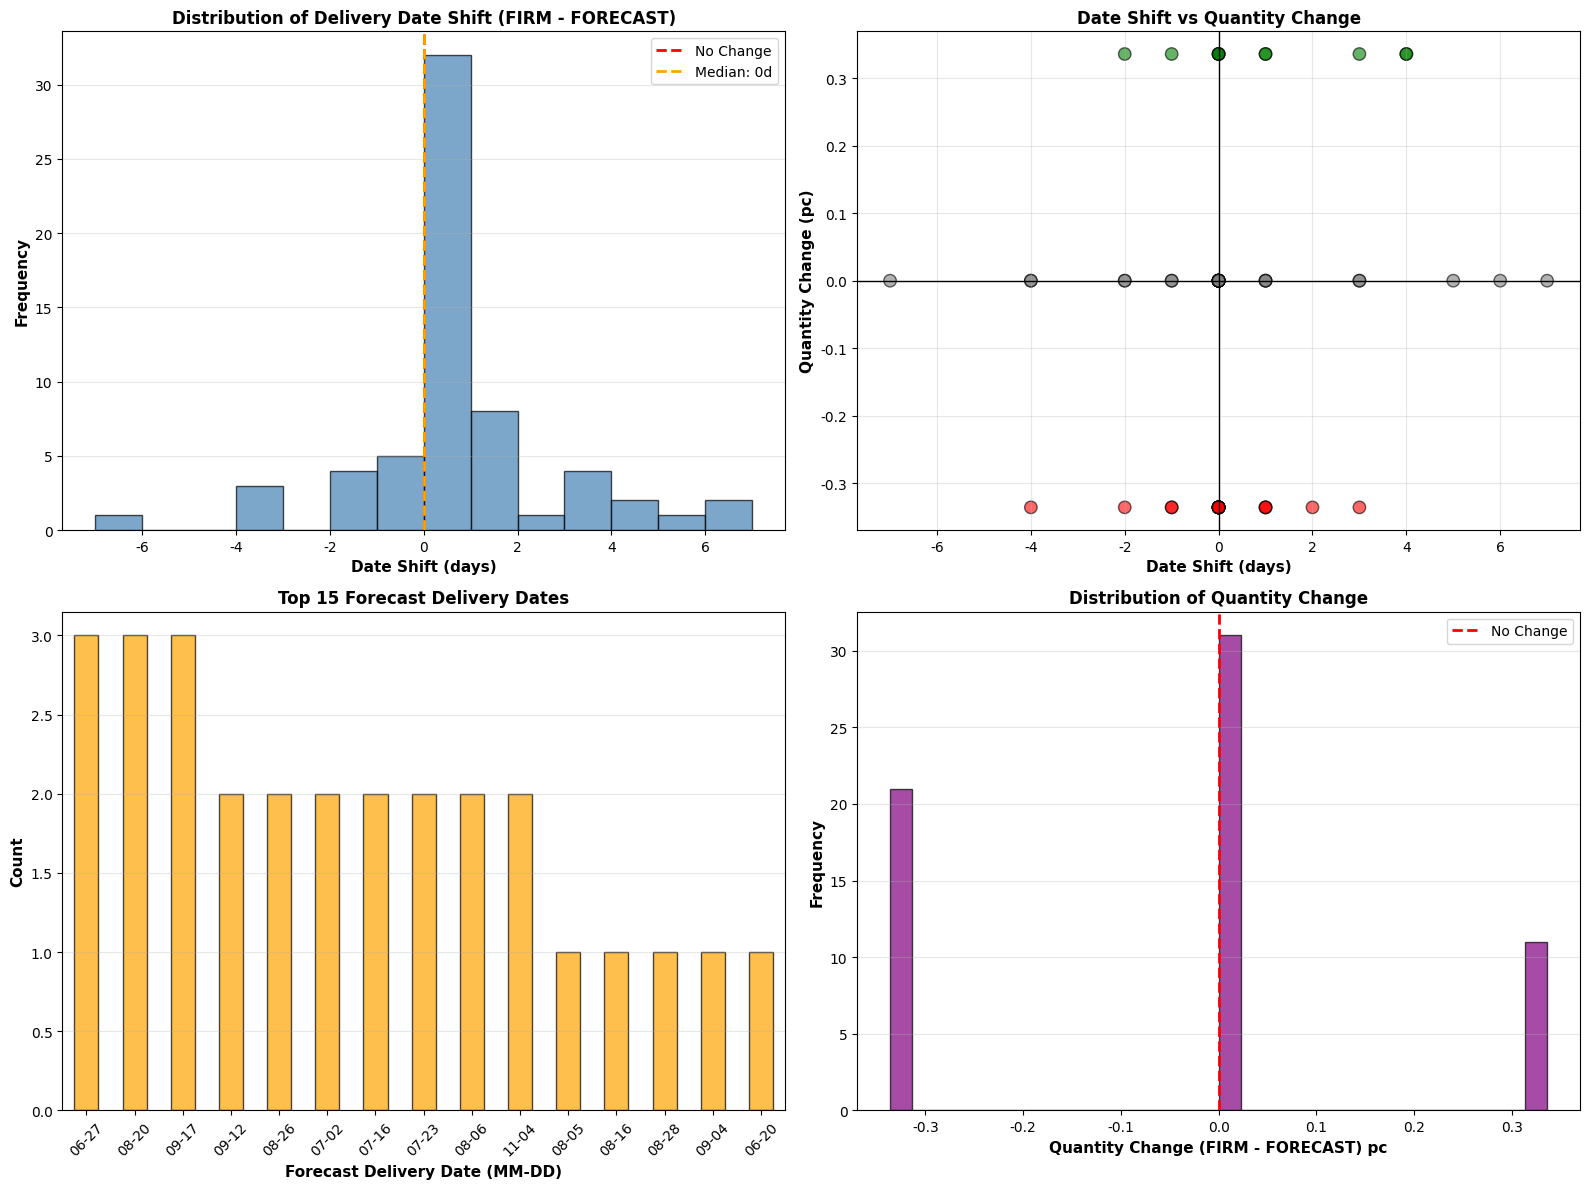

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta


print("="*80)
print("FORECAST vs FIRM 날짜 차이 분석")
print("="*80)

# ID_Release와 납품일 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 분석 1: 유사한 날짜/수량의 FORECAST→FIRM 매칭
# ============================================================================
print("\n" + "="*80)
print("분석 1: 날짜가 약간 다른 FORECAST→FIRM 매칭")
print("="*80)

matched_cases = []

# 모든 FIRM에 대해
firm_df = df[df['Firm/Forecast'] == 'FIRM'].copy()

for idx, firm_row in firm_df.iterrows():
    firm_date = firm_row['Delivery_Date']
    firm_qty = firm_row['Quantity']
    firm_release = firm_row['Release_Date']

    if pd.isna(firm_date):
        continue

    # 이 FIRM보다 이전 ID_Release의 FORECAST 중에서
    # 날짜가 ±7일 이내, 수량이 ±10% 이내인 것 찾기

    candidates = df[
        (df['Firm/Forecast'] == 'FORECAST') &
        (df['Release_Date'] < firm_release) &
        (df['Delivery_Date'].notna()) &
        (abs((df['Delivery_Date'] - firm_date).dt.days) <= 7) &
        (abs(df['Quantity'] - firm_qty) / firm_qty <= 0.1)  # 수량 ±10%
    ]

    if len(candidates) > 0:
        # 가장 가까운 날짜의 FORECAST 선택
        candidates = candidates.copy()
        candidates['date_diff'] = abs((candidates['Delivery_Date'] - firm_date).dt.days)
        closest = candidates.nsmallest(1, 'date_diff').iloc[0]

        date_shift = (firm_date - closest['Delivery_Date']).days
        qty_diff = firm_qty - closest['Quantity']

        matched_cases.append({
            'forecast_release': closest['Release_Date'],
            'firm_release': firm_release,
            'forecast_delivery': closest['Delivery_Date'],
            'firm_delivery': firm_date,
            'date_shift_days': date_shift,
            'forecast_qty': closest['Quantity'],
            'firm_qty': firm_qty,
            'qty_diff': qty_diff,
            'qty_diff_pct': (qty_diff / closest['Quantity']) * 100 if closest['Quantity'] != 0 else 0,
        })

matched_df = pd.DataFrame(matched_cases)

print(f"\n 매칭된 케이스: {len(matched_df)}개")

if len(matched_df) > 0:
    print("\n[날짜 변화 통계]")
    print(f"평균 날짜 변화: {matched_df['date_shift_days'].mean():.2f}일")
    print(f"중앙값 날짜 변화: {matched_df['date_shift_days'].median():.0f}일")
    print(f"표준편차: {matched_df['date_shift_days'].std():.2f}일")

    print("\n[날짜 변화 분포]")
    print(matched_df['date_shift_days'].value_counts().sort_index())

    print("\n[수량 변화 통계]")
    print(f"평균 수량 변화: {matched_df['qty_diff'].mean():.3f}pc ({matched_df['qty_diff_pct'].mean():.2f}%)")
    print(f"수량 동일: {(matched_df['qty_diff'] == 0).sum()}개")
    print(f"수량 증가: {(matched_df['qty_diff'] > 0).sum()}개")
    print(f"수량 감소: {(matched_df['qty_diff'] < 0).sum()}개")

    # 샘플 출력
    print("\n[매칭 샘플 10개]")
    sample = matched_df.head(10)[['forecast_delivery', 'firm_delivery', 'date_shift_days',
                                   'forecast_qty', 'firm_qty', 'qty_diff']]
    print(sample.to_string())

    # ============================================================================
    # 시각화 1: 날짜 변화 분포
    # ============================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1-1: 날짜 변화 히스토그램
    ax = axes[0, 0]
    ax.hist(matched_df['date_shift_days'], bins=range(-7, 8),
           color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    ax.axvline(matched_df['date_shift_days'].median(), color='orange',
              linestyle='--', linewidth=2, label=f"Median: {matched_df['date_shift_days'].median():.0f}d")
    ax.set_xlabel('Date Shift (days)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Delivery Date Shift (FIRM - FORECAST)',
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 1-2: 날짜 변화 vs 수량 변화
    ax = axes[0, 1]
    colors = ['red' if x < 0 else 'green' if x > 0 else 'gray'
              for x in matched_df['qty_diff']]
    ax.scatter(matched_df['date_shift_days'], matched_df['qty_diff'],
              c=colors, alpha=0.6, s=80, edgecolor='black')
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Date Shift (days)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Quantity Change (pc)', fontsize=11, fontweight='bold')
    ax.set_title('Date Shift vs Quantity Change', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 1-3: 날짜별 케이스 수 (원래 FORECAST 날짜 기준)
    ax = axes[1, 0]
    forecast_month_day = matched_df['forecast_delivery'].dt.strftime('%m-%d').value_counts().head(15)
    forecast_month_day.plot(kind='bar', ax=ax, color='orange', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Forecast Delivery Date (MM-DD)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax.set_title('Top 15 Forecast Delivery Dates', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # 1-4: 수량 변화 분포
    ax = axes[1, 1]
    ax.hist(matched_df['qty_diff'], bins=30, color='purple',
           edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    ax.set_xlabel('Quantity Change (FIRM - FORECAST) pc', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Distribution of Quantity Change', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

# ============================================================================
# 분석 2: 특정 패턴 심층 분석
# ============================================================================
print("\n" + "="*80)
print("분석 2: 날짜 변화 패턴 상세 분석")
print("="*80)

if len(matched_df) > 0:
    # 날짜가 밀린 케이스 (+1일 이상)
    delayed = matched_df[matched_df['date_shift_days'] >= 1]
    print(f"\n 납품일이 늦춰진 케이스: {len(delayed)}개")
    if len(delayed) > 0:
        print(f"   평균 지연: {delayed['date_shift_days'].mean():.2f}일")
        print(f"   최대 지연: {delayed['date_shift_days'].max()}일")

    # 날짜가 당겨진 케이스 (-1일 이하)
    advanced = matched_df[matched_df['date_shift_days'] <= -1]
    print(f"\n 납품일이 당겨진 케이스: {len(advanced)}개")
    if len(advanced) > 0:
        print(f"   평균 앞당김: {abs(advanced['date_shift_days'].mean()):.2f}일")
        print(f"   최대 앞당김: {abs(advanced['date_shift_days'].min())}일")

    # 날짜 동일한 케이스
    same_date = matched_df[matched_df['date_shift_days'] == 0]
    print(f"\n 납품일 변화 없음: {len(same_date)}개")

    # 수량은 동일하지만 날짜만 바뀐 케이스
    same_qty_diff_date = matched_df[
        (matched_df['qty_diff'].abs() < 0.01) &
        (matched_df['date_shift_days'] != 0)
    ]
    print(f"\n 수량 동일 + 날짜만 변경: {len(same_qty_diff_date)}개")
    if len(same_qty_diff_date) > 0:
        print("   → 이건 순수한 '납품일 조정' 케이스")
        print(f"   평균 날짜 변화: {same_qty_diff_date['date_shift_days'].mean():.2f}일")

        print("\n   [샘플 5개]")
        sample = same_qty_diff_date.head(5)[['forecast_delivery', 'firm_delivery',
                                             'date_shift_days', 'forecast_qty', 'firm_qty']]
        print(sample.to_string())

    # +1~+3일 밀린 케이스 (질문하신 케이스)
    one_to_three = matched_df[matched_df['date_shift_days'].between(1, 3)]
    print(f"\n 1~3일 늦춰진 케이스: {len(one_to_three)}개")
    if len(one_to_three) > 0:
        print(f"   평균 지연: {one_to_three['date_shift_days'].mean():.2f}일")

        # 이 중 수량도 동일한 케이스
        same_qty_123 = one_to_three[one_to_three['qty_diff'].abs() < 0.01]
        print(f"   그 중 수량 동일: {len(same_qty_123)}개")
        print("   → 발주 지연 가능성")

        print("\n   [1~3일 지연 샘플 10개]")
        sample = one_to_three.head(10)[['forecast_delivery', 'firm_delivery',
                                        'date_shift_days', 'forecast_qty', 'firm_qty', 'qty_diff']]
        print(sample.to_string())


# ============================================================================
# 분석 3: 정확히 동일한 날짜 매칭 확인
# ============================================================================
print("\n" + "="*80)
print("분석 3: 정확히 같은 날짜 FORECAST→FIRM 전환")
print("="*80)

exact_match_cases = []

for idx, firm_row in firm_df.iterrows():
    firm_date = firm_row['Delivery_Date']
    firm_qty = firm_row['Quantity']
    firm_release = firm_row['Release_Date']

    if pd.isna(firm_date):
        continue

    # 정확히 같은 날짜의 이전 FORECAST
    exact_forecasts = df[
        (df['Firm/Forecast'] == 'FORECAST') &
        (df['Release_Date'] < firm_release) &
        (df['Delivery_Date'] == firm_date)
    ]

    if len(exact_forecasts) > 0:
        exact_match_cases.append({
            'delivery_date': firm_date,
            'forecast_count': len(exact_forecasts),
            'firm_release': firm_release,
        })

print(f"정확히 같은 날짜로 전환된 케이스: {len(exact_match_cases)}개")

# ============================================================================
# 최종 요약
# ============================================================================
print("\n" + "="*80)
print("최종 요약")
print("="*80)

total_firm = len(firm_df)
print(f"\n전체 FIRM: {total_firm}개")
print(f"유사 날짜로 매칭됨 (±7일): {len(matched_df)}개 ({len(matched_df)/total_firm*100:.1f}%)")
print(f"정확히 같은 날짜: {len(exact_match_cases)}개 ({len(exact_match_cases)/total_firm*100:.1f}%)")

if len(matched_df) > 0:
    print(f"\n[날짜 변화 요약]")
    print(f"늦춰짐 (+1일 이상): {len(delayed)}개")
    print(f"동일 (0일): {len(same_date)}개")
    print(f"앞당겨짐 (-1일 이하): {len(advanced)}개")

    print(f"\n[특별 케이스]")
    print(f"1~3일 지연: {len(one_to_three)}개")
    print(f"수량 동일 + 날짜만 변경: {len(same_qty_diff_date)}개")

print("\n분석 완료!")

In [ ]:
df['Firm/Forecast'].value_counts()

,count
Firm/Forecast,
FORECAST,4569
FIRM,87


전체 FIRM: 87개

60개는 날짜까지 완전히 동일하게 firm으로 전환
나머지 27개는 날짜 변경된 채로 firm으로 바뀜

좌상: Distribution of Delivery Date Shift
X축: Date Shift (days)

의미: FIRM 납품일 - FORECAST 납품일 (일 단위)
예시:

0일: FORECAST 2024-08-20 → FIRM 2024-08-20 (동일)
+3일: FORECAST 2024-08-20 → FIRM 2024-08-23 (3일 늦춤)
-2일: FORECAST 2024-08-20 → FIRM 2024-08-18 (2일 앞당김)

Y축: Frequency

의미: 각 날짜 변화가 발생한 건수
예시:

0일 변화 = 32건
+1일 변화 = 8건


우상: Date Shift vs Quantity Change
X축: Date Shift (days)

의미: 위와 동일 (FIRM 날짜 - FORECAST 날짜)
범위: -7일 ~ +7일

Y축: Quantity Change (pc)

의미: FIRM 수량 - FORECAST 수량 (piece 단위)
예시:

0.0: FORECAST 4.368pc → FIRM 4.368pc (수량 동일)
+0.336: FORECAST 4.368pc → FIRM 4.704pc (0.336pc 증가)
-0.336: FORECAST 4.704pc → FIRM 4.368pc (0.336pc 감소)


점의 색깔:

빨간색: 수량 감소 (음수)
회색: 수량 동일 (0)
초록색: 수량 증가 (양수)


좌하: Top 15 Forecast Delivery Dates
X축: Forecast Delivery Date (MM-DD)

의미: FORECAST의 원래 납품 예정일 (월-일)
예시:

08-21: 8월 21일 납품 예정이었던 주문
09-17: 9월 17일 납품 예정이었던 주문

Y축: Count

의미: 해당 날짜로 예측된 주문 건수
예시:

08-21 납품 예정 = 3건
08-20 납품 예정 = 3건


우하: Distribution of Quantity Change
X축: Quantity Change (FIRM - FORECAST) pc

의미: FIRM 수량 - FORECAST 수량 (piece 단위)
예시:

0.0: 수량 변화 없음
+0.336: 0.336pc 증가
-0.336: 0.336pc 감소

Y축: Frequency

의미: 각 수량 변화가 발생한 건수
예시:

0.0 변화 = 31건
-0.336 변화 = 21건
+0.336 변화 = 11건

#  수요량이 얼마나 차이가 있는지 확인해보기, 갑작스러운 주문이(신주문) 들어왔을 때의 패턴들 보기

A0067885

각 ID_Release별 마지막 납품일 추적 분석

총 74개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     74.000000       74.000000   74.000000              74.000000   
mean      62.621622       61.743243    0.878378              61.797297   
std       12.654203       12.889478    0.890632              10.544075   
min       43.000000       43.000000    0.000000              43.000000   
25%       53.500000       53.250000    0.000000              53.500000   
50%       61.000000       60.000000    1.000000              61.000000   
75%       69.000000       68.500000    1.750000              68.500000   
max      122.000000      122.000000    3.000000              84.000000   

       delivery_range_days  
count            74.000000  
mean            468.608108  
std              72.777728  
min             307.000000  
25%             421.250000  
50%             455.000000  
75%             529.000000  
max             628.000000  


/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3275809614.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 3건

[신규 주문 유입 이벤트]

ID_Release: 2024-12-02
  마지막 납품일 변화: +259일
  새 마지막 납품일: 2026-07-22
  전체 주문: 79건 (FORECAST: 79, FIRM: 0)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-01-06
  마지막 납품일 변화: +70일
  새 마지막 납품일: 2026-09-30
  전체 주문: 84건 (FORECAST: 83, FIRM: 1)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-09-01
  마지막 납품일 변화: +35일
  새 마지막 납품일: 2026-11-25
  전체 주문: 57건 (FORECAST: 56, FIRM: 1)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 0건

ID_Release × 납품일 히트맵 생성

분석 완료!


/tmp/ipykernel_9333/3275809614.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  

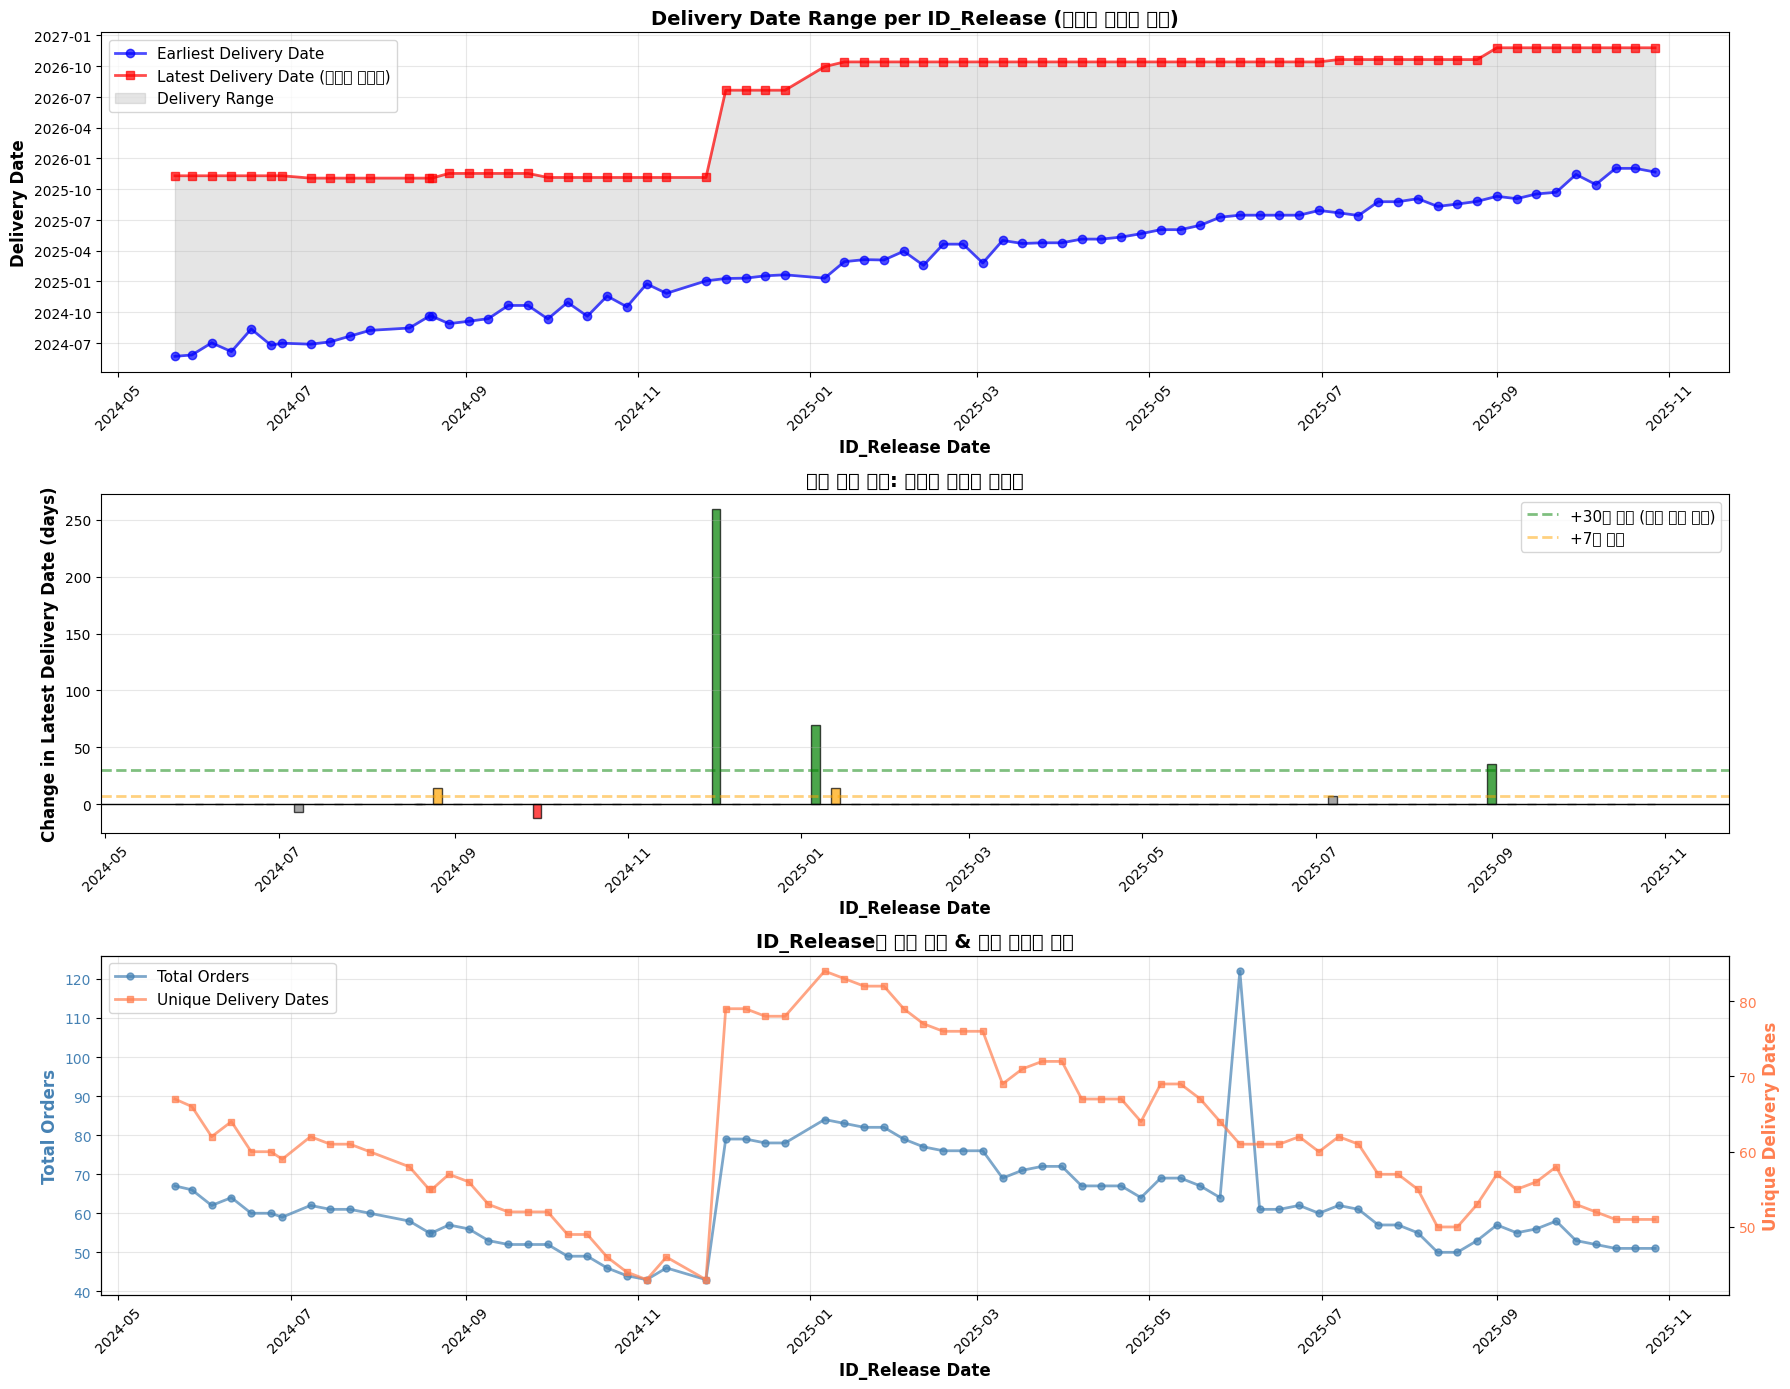

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


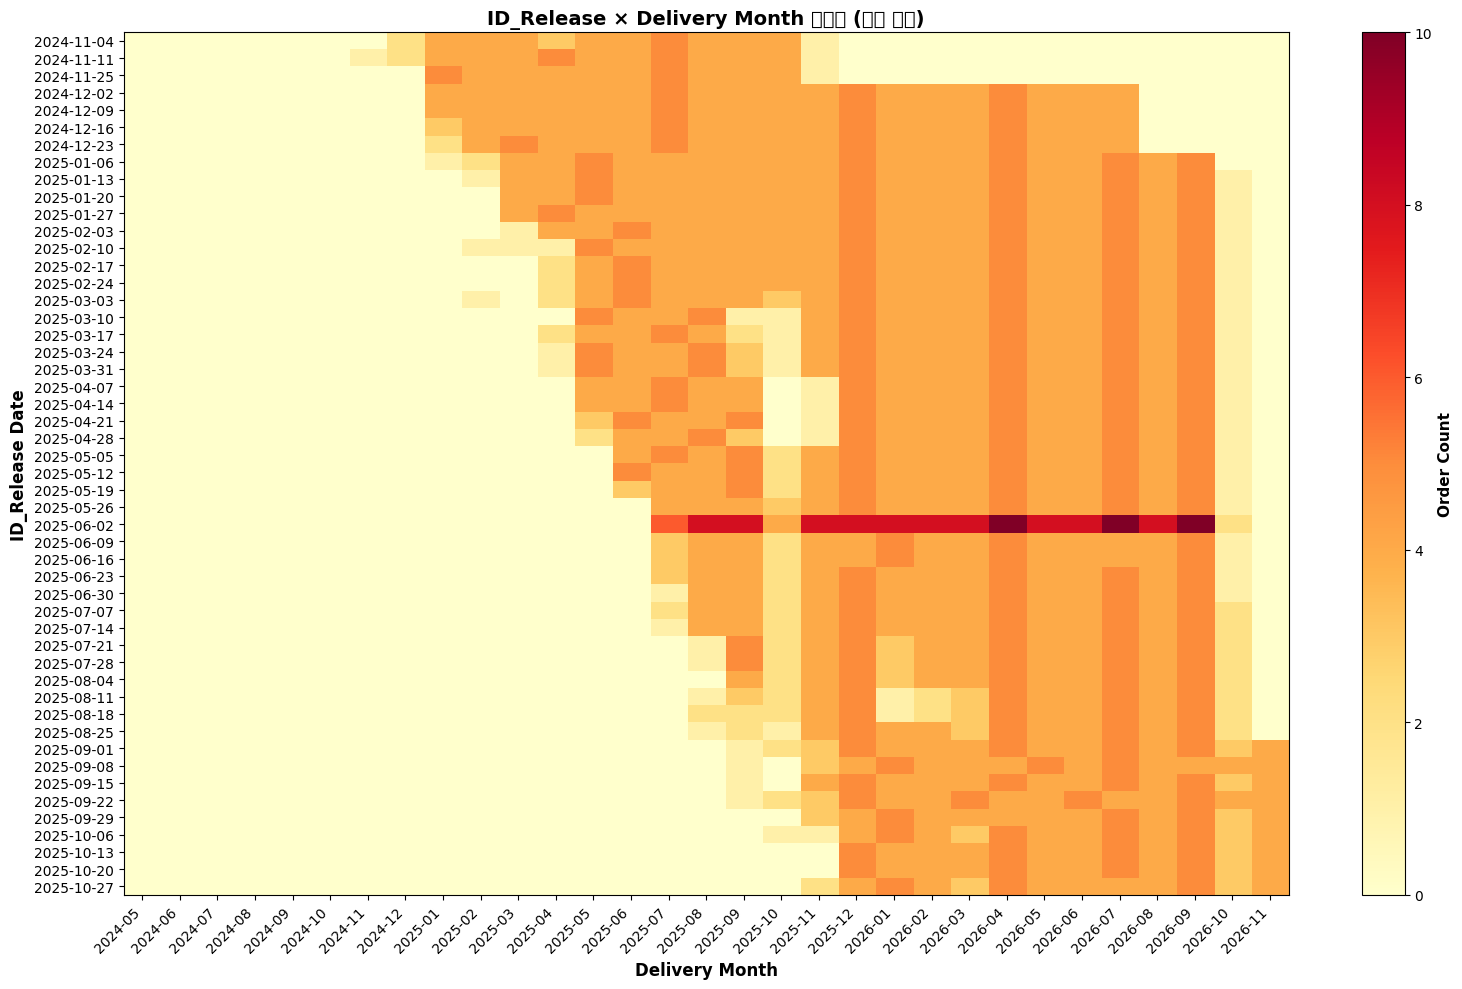

In [4]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A0067885_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)

가운데 그래프만 보면 됨

① 2024-12월경 → +258일 (초록 막대, 가장 큰 이벤트)

마지막 납품일이 갑자기 258일 늘어남
신규 대량 장기 주문이 유입된 시점
이전까지 없던 먼 미래 납품 일정이 새로 생겼다는 의미

② 2025-01월 → +68일

또 한 번 추가 장기 주문 유입
연속해서 납품 범위가 확장되는 중

③ 2024-10월 → 소폭 음수 (빨간 막대)

마지막 납품일이 약간 줄어듦
기존 주문 일부 취소 또는 일정 조정 가능성

④ 2024-07월, 나머지 구간 → 거의 변화 없음 (회색)

기존 주문 범위 내에서 반복되는 정기 릴리스
새로운 주문 추가 없이 유지되는 상태

/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:41: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh

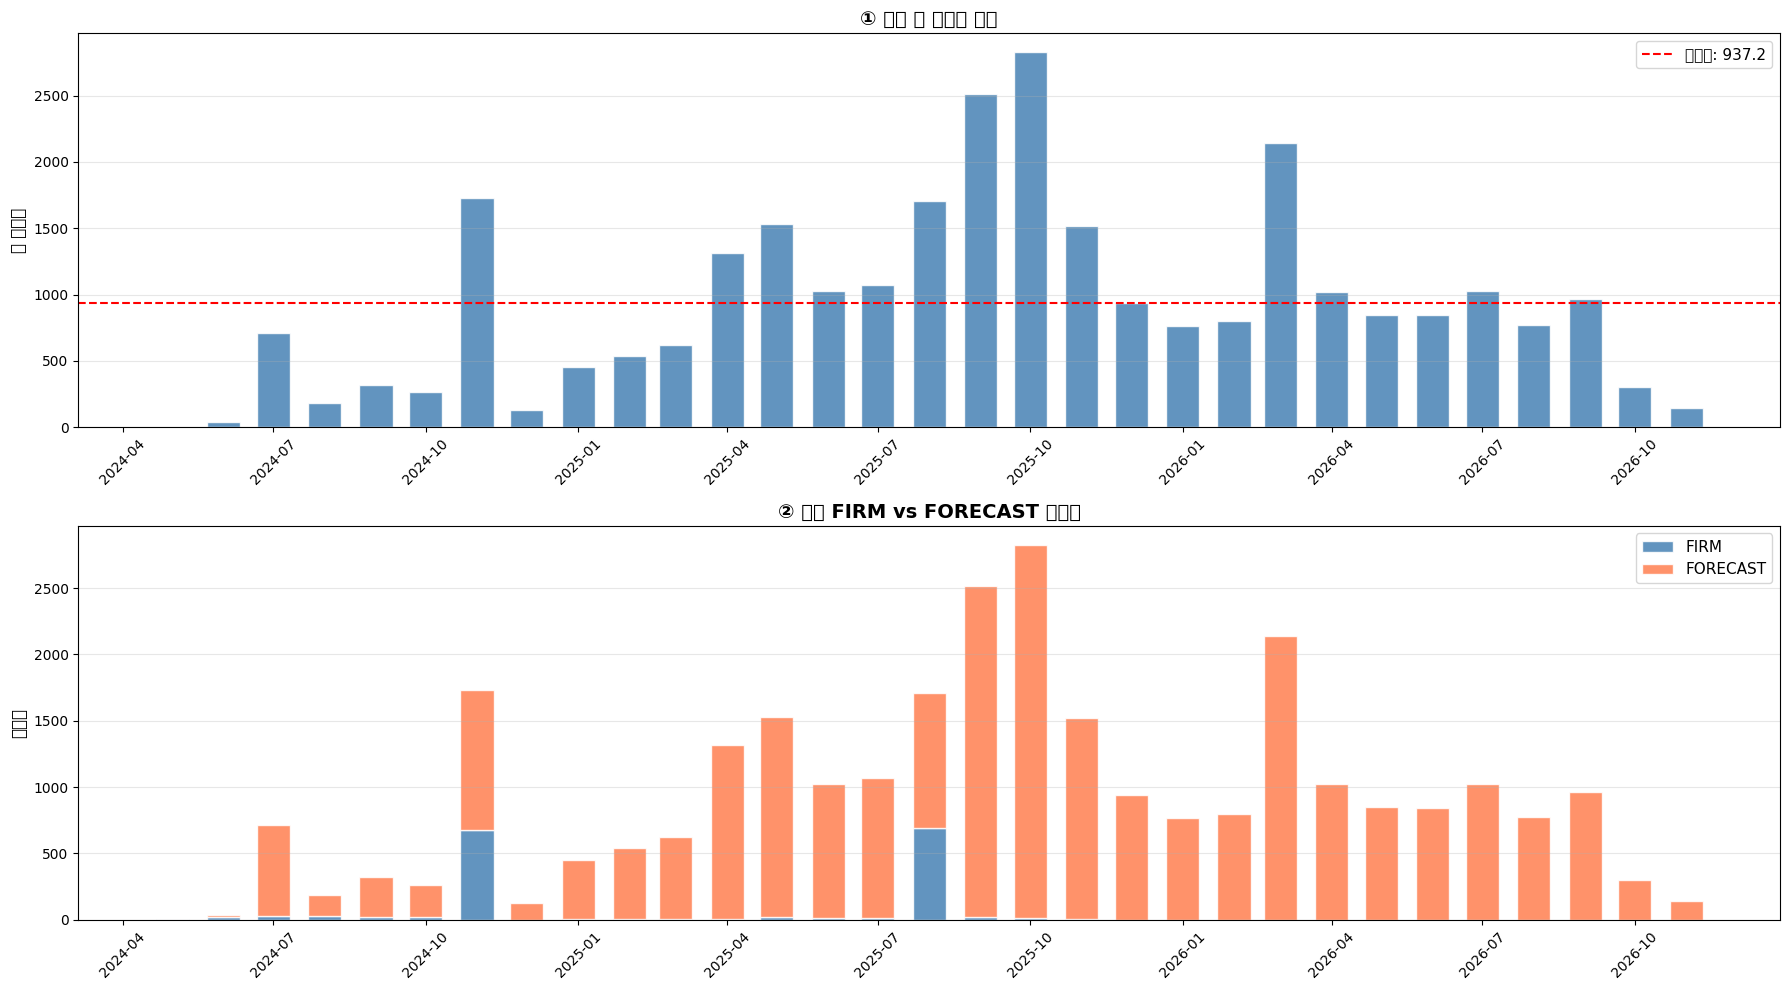

/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3992698928.py:74: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tigh

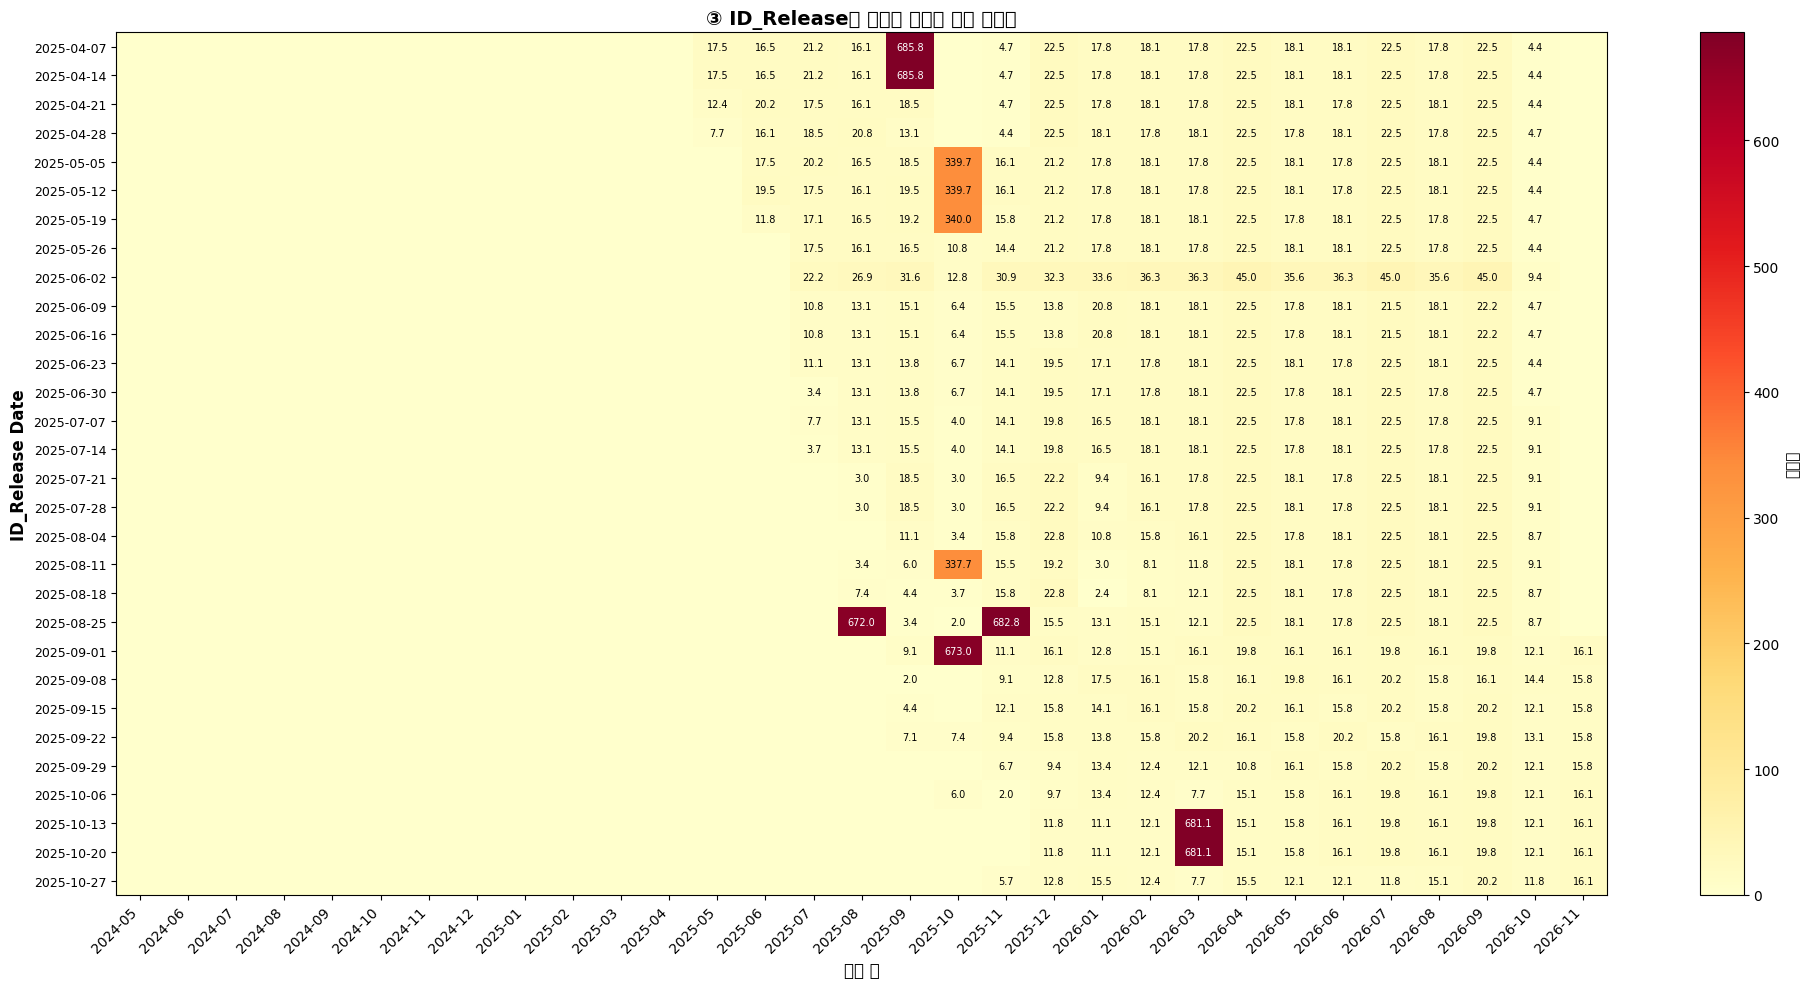


① 월별 수요량 요약
납품월                   FIRM     FORECAST         합계
-----------------------------------------------------------------
2024-05               4.03         0.00       4.03
2024-06              22.18        14.78      36.96
2024-07              24.19       689.14     713.33
2024-08              28.22       157.25     185.47
2024-09              21.50       299.04     320.54
2024-10              22.18       240.24     262.42
2024-11             679.39      1050.34    1729.73
2024-12               0.00       127.34     127.34
2025-01               5.38       447.55     452.93
2025-02               4.70       532.56     537.26
2025-03               2.69       618.58     621.26
2025-04               4.37      1309.06    1313.42
2025-05              17.14      1513.01    1530.14
2025-06              12.77      1010.35    1023.12
2025-07              15.12      1053.02    1068.14
2025-08             689.14      1019.09    1708.22
2025-09              22.51      2490.43    2512.94
202

In [6]:
# ============================================================================
# 월별 수요량 분석 (① + ② + ③ 전체)
# ============================================================================

df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

# ① 월별 총 수요량 추이
monthly_qty = df.groupby('Delivery_Month')['Quantity'].sum().reset_index()
monthly_qty['Month_dt'] = monthly_qty['Delivery_Month'].dt.to_timestamp()

monthly_firm = df[df['Firm/Forecast'] == 'FIRM'].groupby('Delivery_Month')['Quantity'].sum()
monthly_forecast = df[df['Firm/Forecast'] == 'FORECAST'].groupby('Delivery_Month')['Quantity'].sum()
monthly_split = pd.DataFrame({'FIRM': monthly_firm, 'FORECAST': monthly_forecast}).fillna(0).reset_index()
monthly_split['Month_dt'] = monthly_split['Delivery_Month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

ax = axes[0]
ax.bar(monthly_qty['Month_dt'], monthly_qty['Quantity'],
       width=20, color='steelblue', edgecolor='white', alpha=0.85)
avg = monthly_qty['Quantity'].mean()
ax.axhline(y=avg, color='red', linestyle='--', linewidth=1.5, label=f'월평균: {avg:.1f}')
ax.set_title('① 월별 총 수요량 추이', fontsize=14, fontweight='bold')
ax.set_ylabel('총 수요량', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
ax2.bar(monthly_split['Month_dt'], monthly_split['FIRM'],
        width=20, label='FIRM', color='steelblue', edgecolor='white', alpha=0.85)
ax2.bar(monthly_split['Month_dt'], monthly_split['FORECAST'],
        bottom=monthly_split['FIRM'],
        width=20, label='FORECAST', color='coral', edgecolor='white', alpha=0.85)
ax2.set_title('② 월별 FIRM vs FORECAST 수요량', fontsize=14, fontweight='bold')
ax2.set_ylabel('수요량', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# ③ ID_Release별 같은 납품월 수요량 변화 (히트맵)
# ============================================================================
pivot = df.groupby(['Release_Date', 'Delivery_Month'])['Quantity'].sum().unstack(fill_value=0)

# 최근 30개 릴리스만
if len(pivot) > 30:
    pivot = pivot.iloc[-30:]

fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels([str(x) for x in pivot.columns], rotation=45, ha='right', fontsize=10)
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot.index], fontsize=9)

# 셀 값 표시
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                   fontsize=7, color='black' if val < pivot.values.max()*0.6 else 'white')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('수요량', fontsize=11)
ax.set_xlabel('납품 월', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('③ ID_Release별 납품월 수요량 변화 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 수치 요약 출력
# ============================================================================
print("\n" + "="*65)
print("① 월별 수요량 요약")
print("="*65)
print(f"{'납품월':<15} {'FIRM':>10} {'FORECAST':>12} {'합계':>10}")
print("-"*65)
for _, row in monthly_split.iterrows():
    total = row['FIRM'] + row['FORECAST']
    print(f"{str(row['Delivery_Month']):<15} {row['FIRM']:>10.2f} {row['FORECAST']:>12.2f} {total:>10.2f}")

print(f"\n월평균 총 수요량: {monthly_qty['Quantity'].mean():.2f}")
print(f"최대 수요 월: {monthly_qty.loc[monthly_qty['Quantity'].idxmax(), 'Delivery_Month']} "
      f"({monthly_qty['Quantity'].max():.2f})")
print(f"최소 수요 월: {monthly_qty.loc[monthly_qty['Quantity'].idxmin(), 'Delivery_Month']} "
      f"({monthly_qty['Quantity'].min():.2f})")

print("\n" + "="*65)
print("② FIRM 비중이 높은 상위 5개월")
print("="*65)
monthly_split['FIRM_ratio'] = monthly_split['FIRM'] / (monthly_split['FIRM'] + monthly_split['FORECAST']) * 100
top_firm = monthly_split.nlargest(5, 'FIRM_ratio')[['Delivery_Month', 'FIRM', 'FORECAST', 'FIRM_ratio']]
for _, row in top_firm.iterrows():
    print(f"{str(row['Delivery_Month']):<15} FIRM 비중: {row['FIRM_ratio']:.1f}%")

print("\n" + "="*65)
print("③ 납품월별 수요량 변동성 (표준편차 상위 5개월)")
print("="*65)
monthly_std = df.groupby('Delivery_Month')['Quantity'].std().nlargest(5)
for month, std in monthly_std.items():
    print(f"{str(month):<15} 표준편차: {std:.2f}")

/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1511662882.py:42: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tig

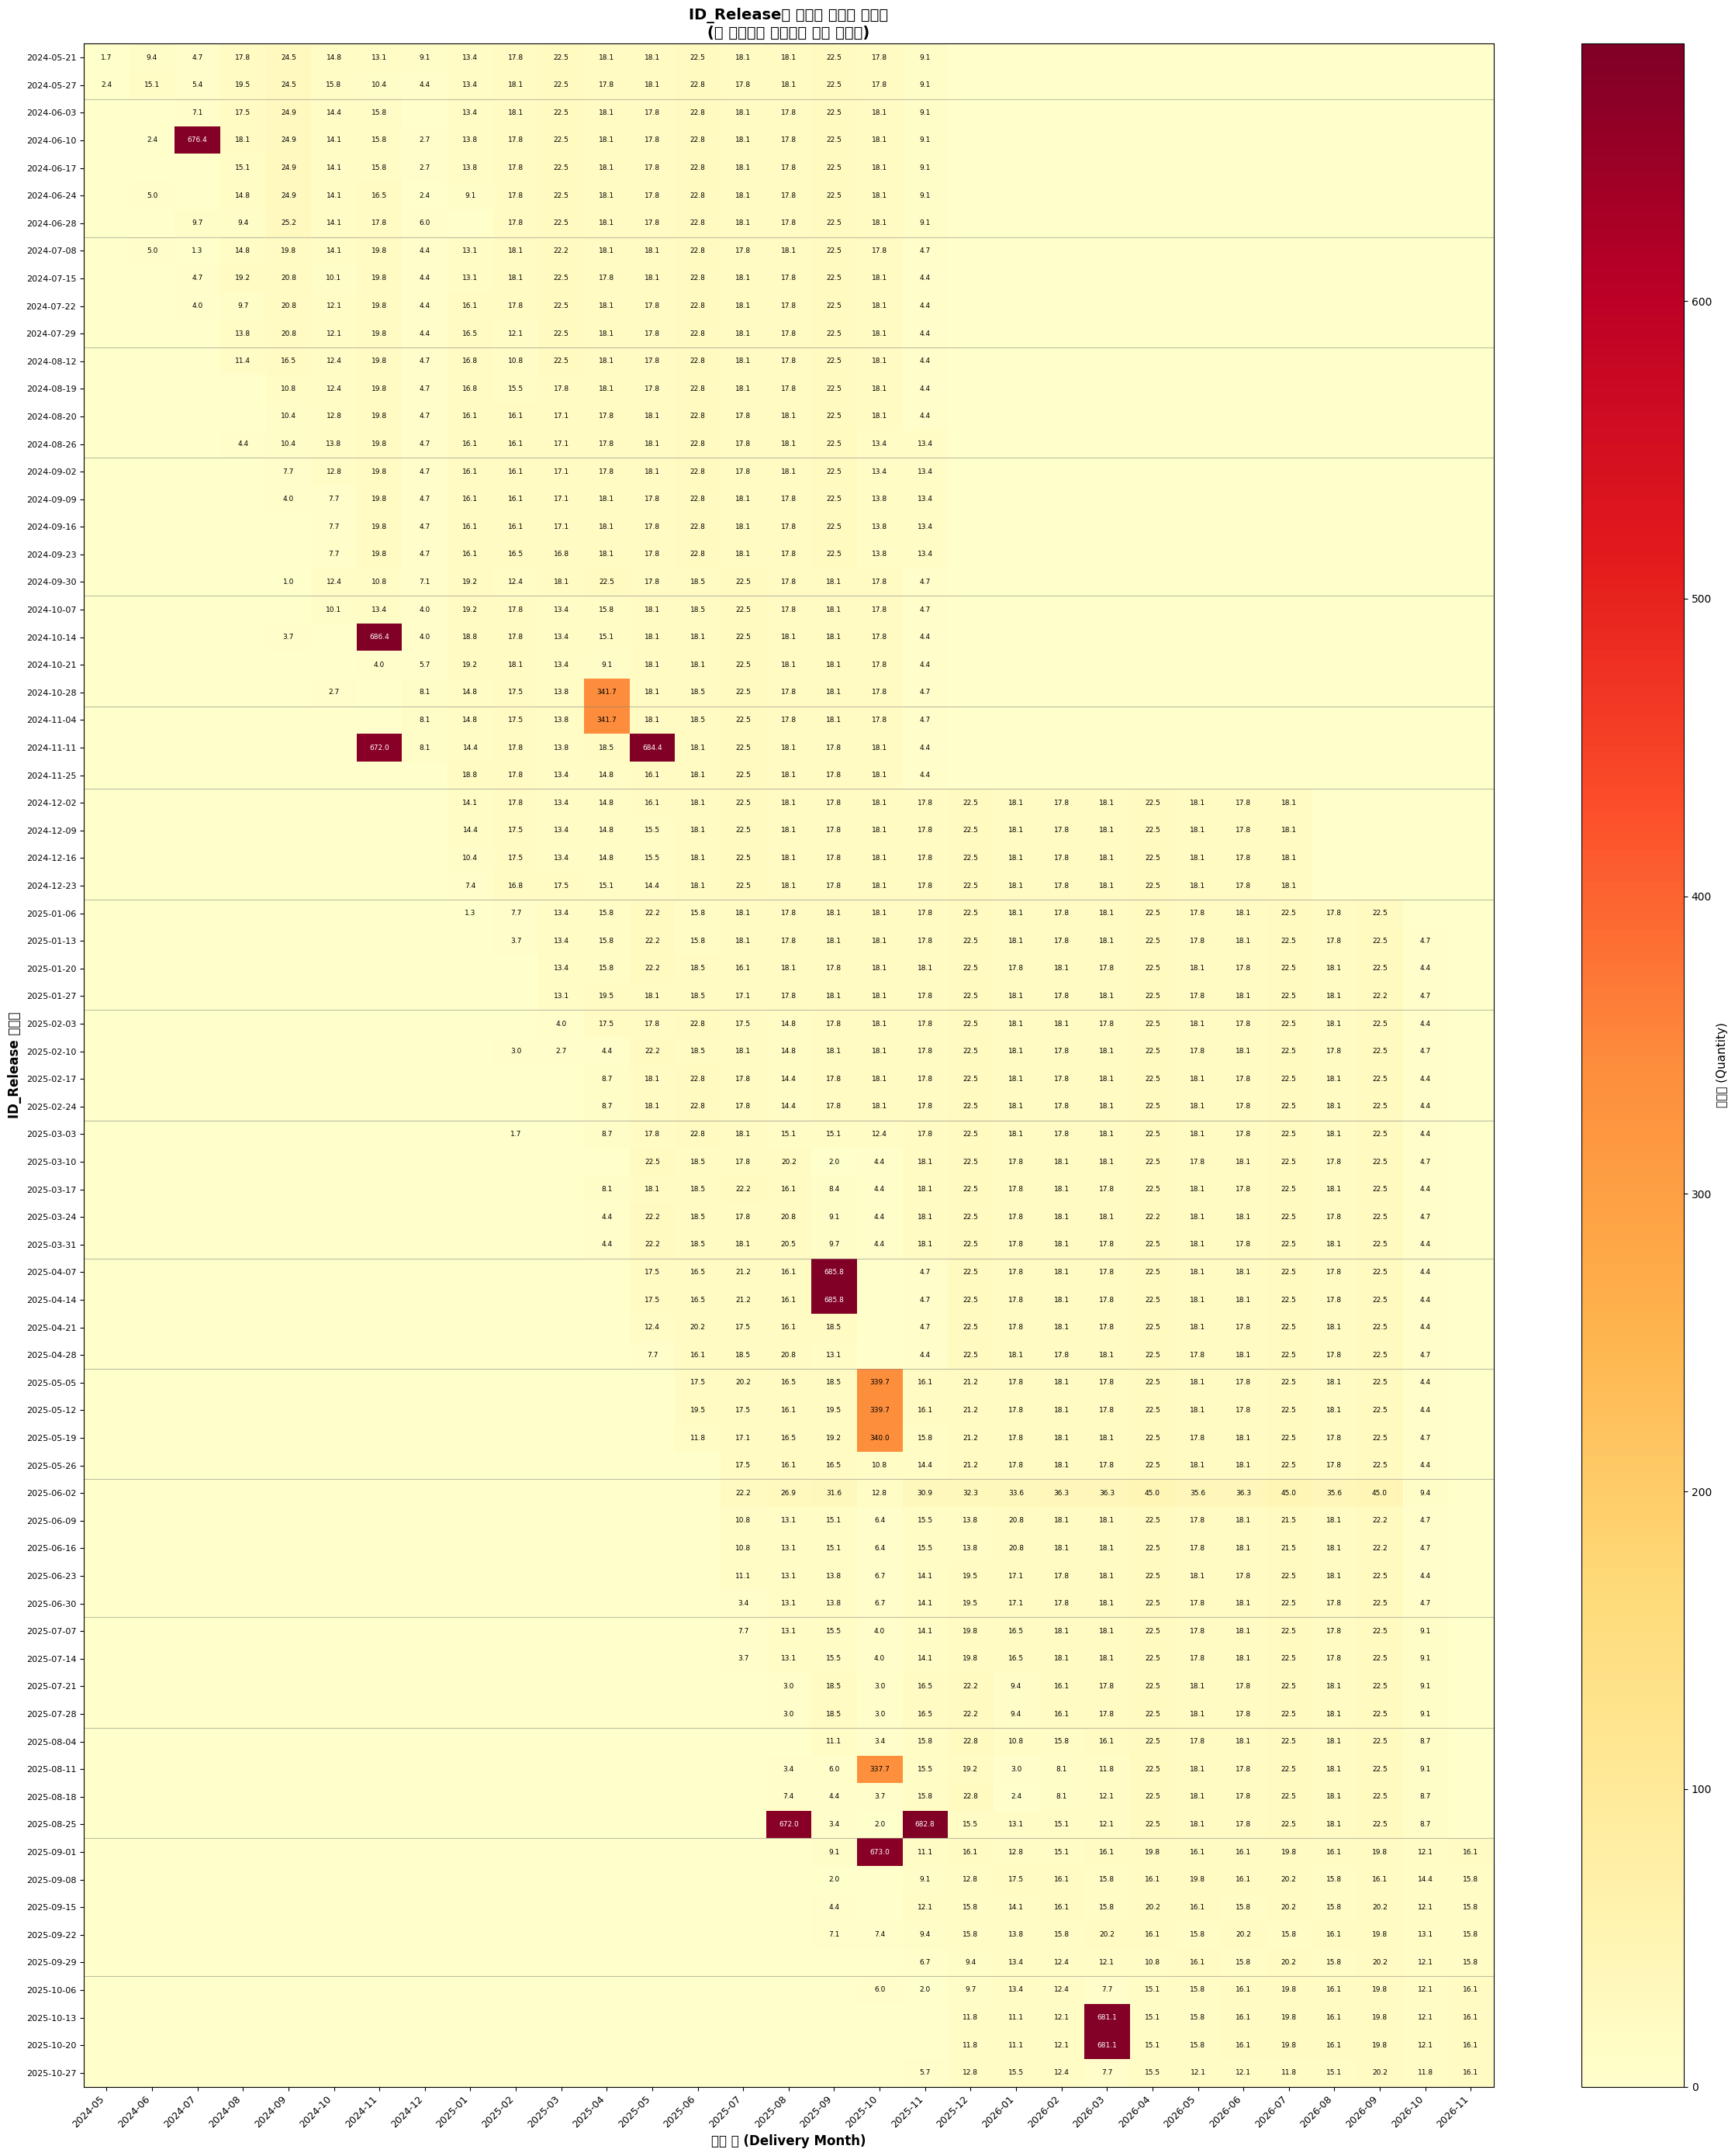


ID_Release별 주요 수치 요약
릴리스일                  총수요량     납품월수           최대납품월       최대수량
----------------------------------------------------------------------
2024-05-21     )      293.3       19         2024-09       24.5
2024-05-27     )      295.7       19         2024-09       24.5
2024-06-03     )      278.2       16         2024-09       24.9
2024-06-10     )      952.9       18         2024-07      676.4
2024-06-17     )      271.2       16         2024-09       24.9
2024-06-24     )      271.5       17         2024-09       24.9
2024-06-28     )      267.1       16         2024-09       25.2
2024-07-08     )      272.8       18         2025-06       22.8
2024-07-15     )      272.5       17         2025-06       22.8
2024-07-22     )      267.1       17         2025-06       22.8
2024-07-29     )      261.7       16         2025-06       22.8
2024-08-12     )      254.7       16         2025-06       22.8
2024-08-19     )      237.6       15         2025-06       22.8
2024-08-20  

In [10]:
# ============================================================================
# ID_Release별 납품월 수요량 히트맵 (전체 릴리스)
# ============================================================================

df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot = df.groupby(['Release_Date', 'Delivery_Month'])['Quantity'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(24, len(pivot) * 0.35 + 2))

im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels([str(x) for x in pivot.columns], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot.index], fontsize=8)

# 셀 값 표시 (0 제외)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            text_color = 'white' if val > pivot.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=6.5, color=text_color)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('수요량 (Quantity)', fontsize=11)

ax.set_xlabel('납품 월 (Delivery Month)', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release 발행일', fontsize=12, fontweight='bold')
ax.set_title('ID_Release별 납품월 수요량 히트맵\n(각 릴리스가 바라보는 월별 수요량)',
             fontsize=14, fontweight='bold')

# 릴리스 날짜 구분선 (월 경계마다)
release_months = pd.Series([x.strftime('%Y-%m')
                             for x in pivot.index])
for i in range(1, len(release_months)):
    if release_months[i] != release_months[i-1]:
        ax.axhline(y=i - 0.5, color='gray', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

# ============================================================================
# 릴리스별 수치 요약 출력
# ============================================================================
print("\n" + "="*70)
print("ID_Release별 주요 수치 요약")
print("="*70)
print(f"{'릴리스일':<15} {'총수요량':>10} {'납품월수':>8} {'최대납품월':>15} {'최대수량':>10}")
print("-"*70)

for release_date, row in pivot.iterrows():
    nonzero = row[row > 0]
    if len(nonzero) == 0:
        continue
    total = nonzero.sum()
    max_month = str(nonzero.idxmax())
    max_qty = nonzero.max()
    n_months = len(nonzero)
    print(f"{str(release_date)[:10]:<15}) {total:>10.1f} {n_months:>8} {max_month:>15} {max_qty:>10.1f}")

A0028219

각 ID_Release별 마지막 납품일 추적 분석

총 76개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     76.000000       76.000000   76.000000              76.000000   
mean      64.855263       63.776316    1.078947              64.210526   
std       11.811524       11.738937    0.962818              10.952401   
min       42.000000       41.000000    0.000000              42.000000   
25%       57.000000       55.750000    0.000000              56.750000   
50%       63.000000       63.000000    1.000000              63.000000   
75%       74.000000       72.250000    2.000000              72.500000   
max      104.000000      102.000000    4.000000              86.000000   

       delivery_range_days  
count            76.000000  
mean            477.513158  
std              71.367685  
min             316.000000  
25%             432.500000  
50%             472.500000  
75%             532.250000  
max             618.000000  


/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 3건

[신규 주문 유입 이벤트]

ID_Release: 2024-12-02
  마지막 납품일 변화: +268일
  새 마지막 납품일: 2026-07-24
  전체 주문: 78건 (FORECAST: 77, FIRM: 1)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-06-16
  마지막 납품일 변화: +106일
  새 마지막 납품일: 2026-11-11
  전체 주문: 62건 (FORECAST: 62, FIRM: 0)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-08-18
  마지막 납품일 변화: +177일
  새 마지막 납품일: 2027-05-14
  전체 주문: 86건 (FORECAST: 85, FIRM: 1)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 0건

ID_Release × 납품일 히트맵 생성


/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3339889854.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.ti


분석 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) mi

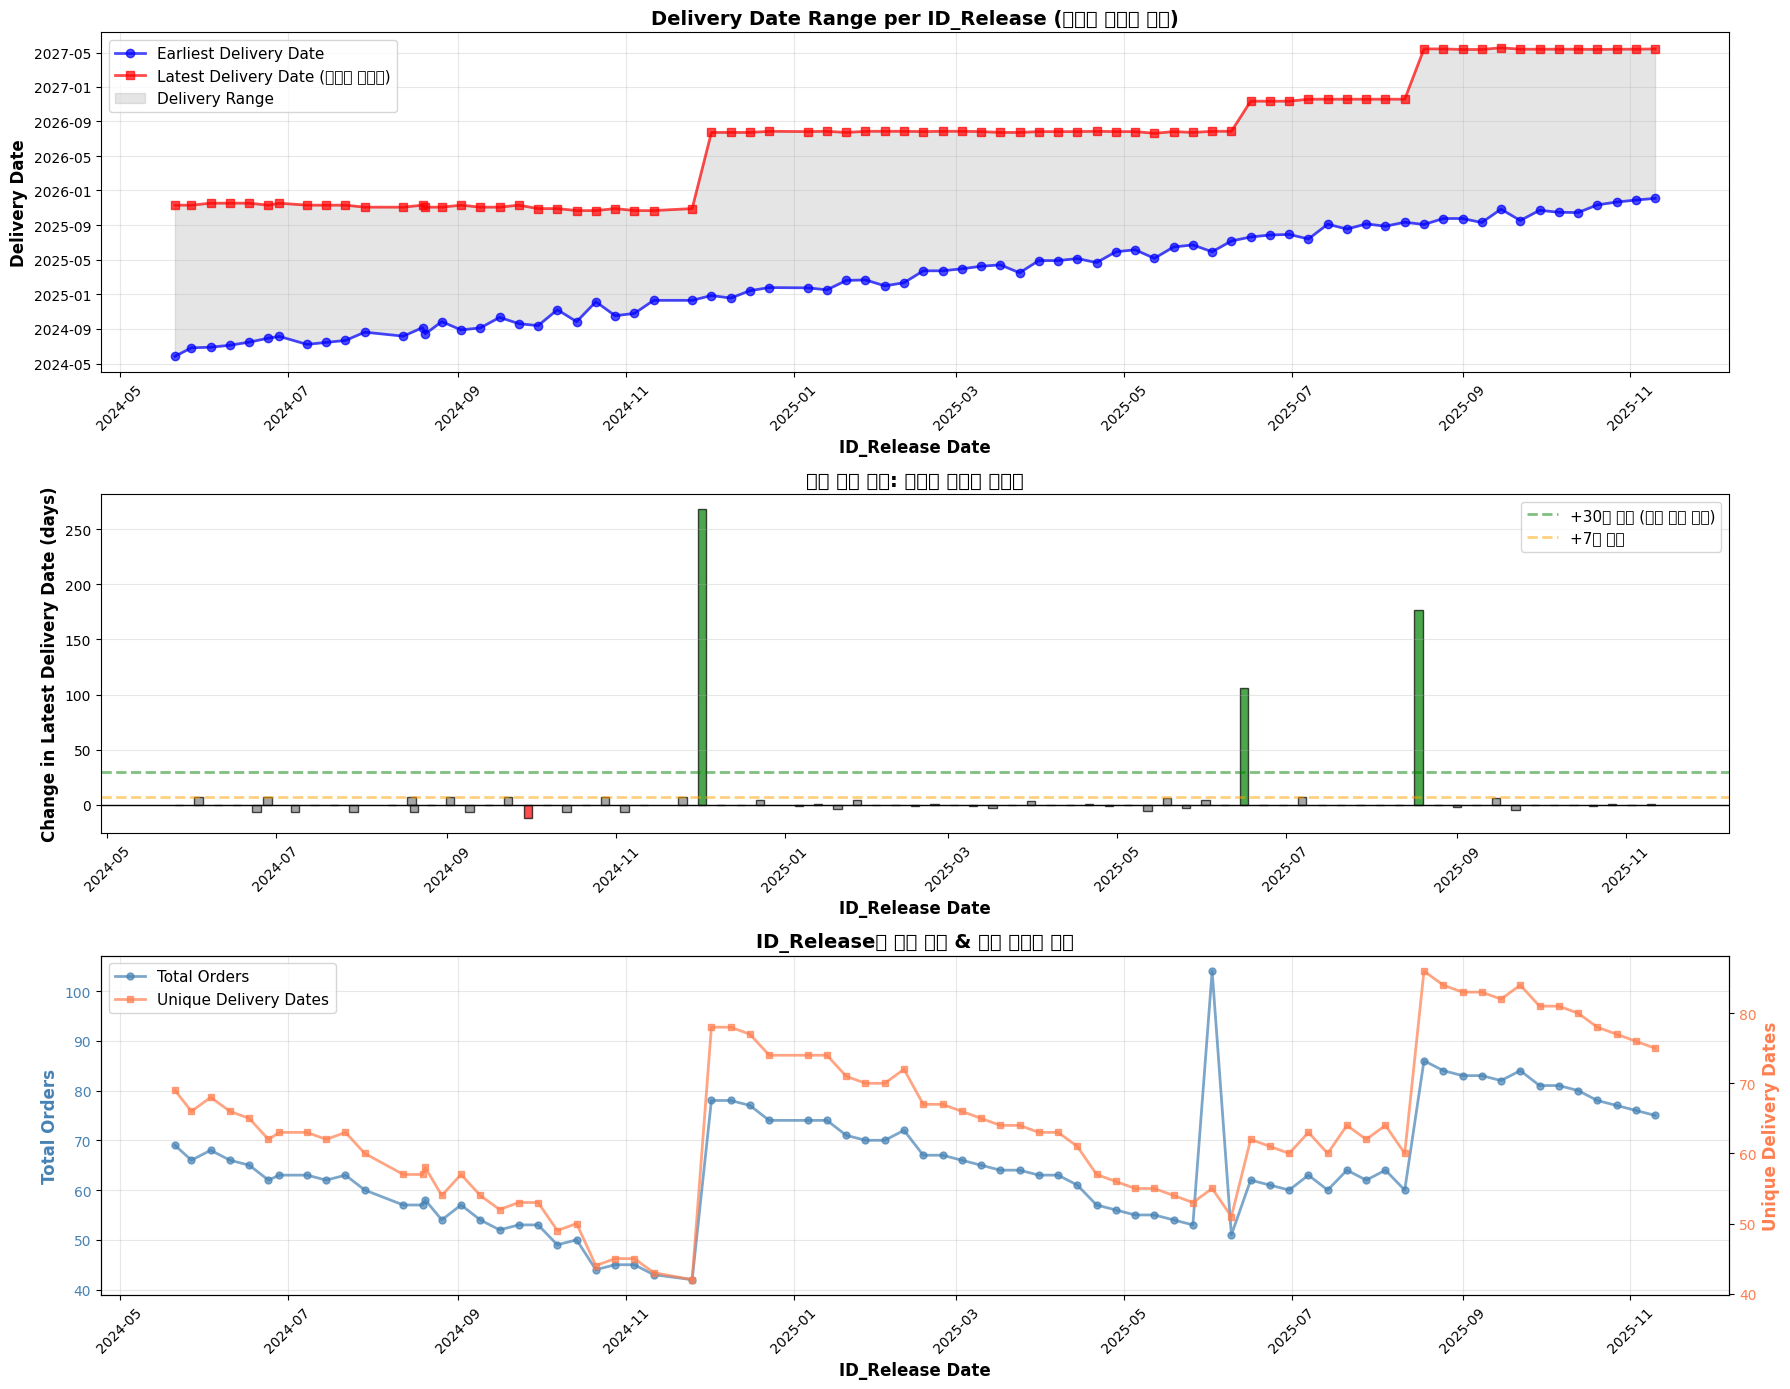

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


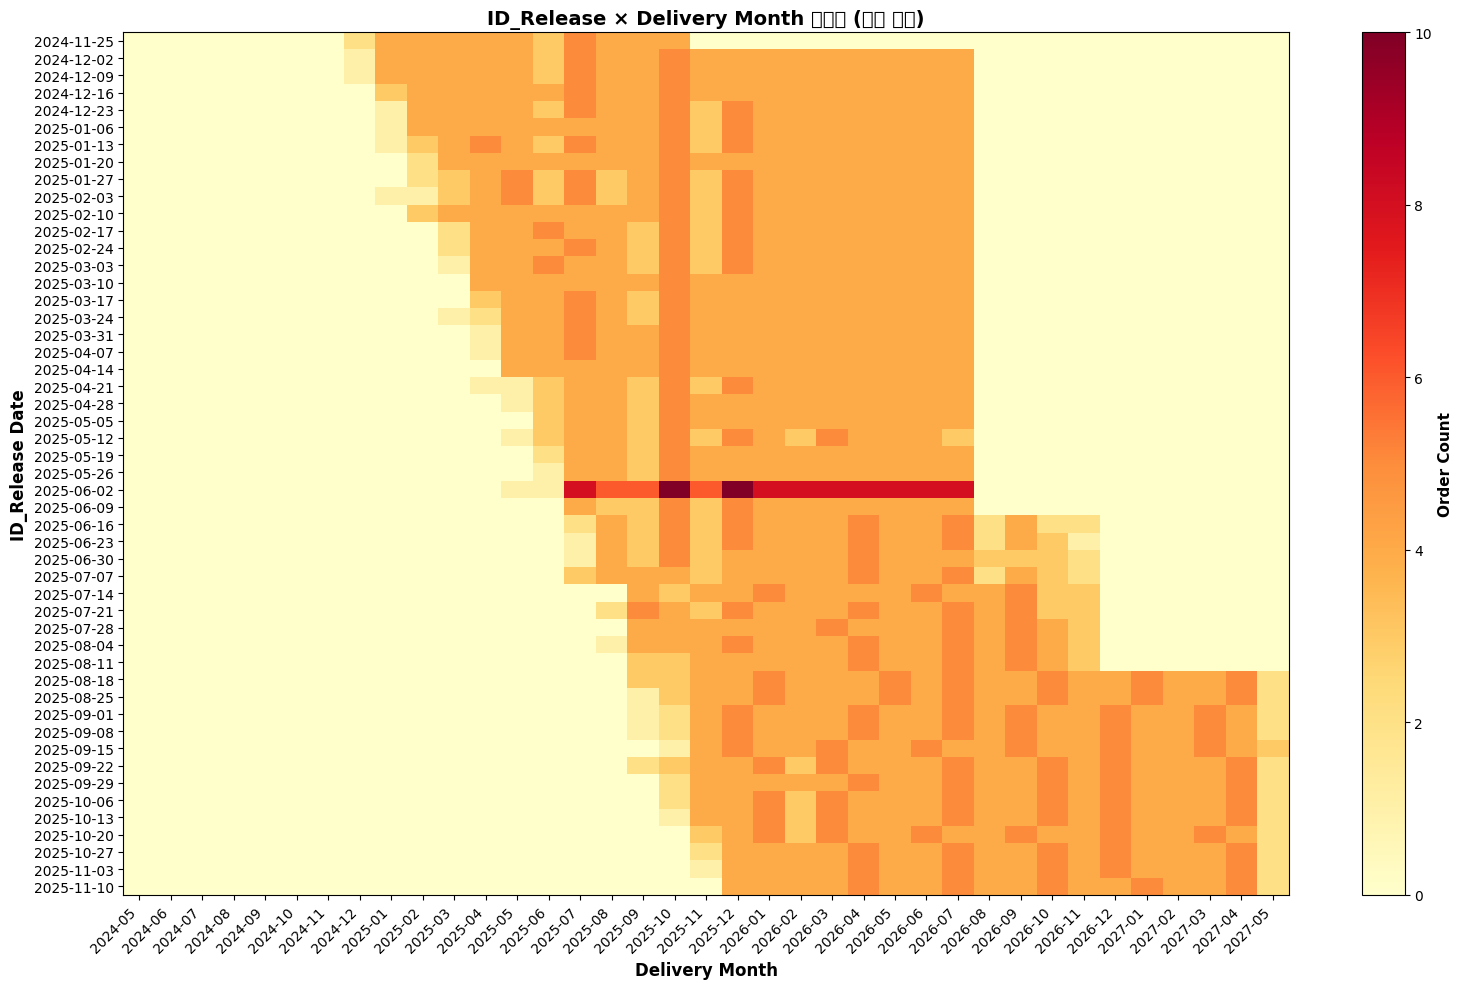

In [11]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A0028219_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)

A0049000

각 ID_Release별 마지막 납품일 추적 분석

총 76개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     76.000000       76.000000   76.000000              76.000000   
mean      67.618421       66.473684    1.144737              66.894737   
std       11.708649       11.578686    0.890003              10.573651   
min       43.000000       43.000000    0.000000              43.000000   
25%       59.000000       58.750000    0.750000              58.750000   
50%       67.000000       66.000000    1.000000              67.000000   
75%       77.000000       75.000000    2.000000              75.500000   
max      112.000000      110.000000    3.000000              86.000000   

       delivery_range_days  
count            76.000000  
mean            477.263158  
std              73.183307  
min             300.000000  
25%             422.250000  
50%             479.000000  
75%             539.750000  
max             629.000000  


/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 4건

[신규 주문 유입 이벤트]

ID_Release: 2024-12-02
  마지막 납품일 변화: +266일
  새 마지막 납품일: 2026-07-20
  전체 주문: 81건 (FORECAST: 81, FIRM: 0)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-06-16
  마지막 납품일 변화: +112일
  새 마지막 납품일: 2026-11-09
  전체 주문: 70건 (FORECAST: 69, FIRM: 1)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-08-18
  마지막 납품일 변화: +175일
  새 마지막 납품일: 2027-05-10
  전체 주문: 86건 (FORECAST: 85, FIRM: 1)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-11-03
  마지막 납품일 변화: +77일
  새 마지막 납품일: 2027-07-30
  전체 주문: 78건 (FORECAST: 77, FIRM: 1)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 1건

[주문 감소 이벤트]

ID_Release: 2025-11-10
  마지막 납품일 변화: -79일
  새 마지막 납품일: 2027-05-12
  전체 주문: 77건
  → 장기 주문 취소 또는 완료 가능성

ID_Release × 납품일 히트맵 생성


/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1994325769.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.ti


분석 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) mi

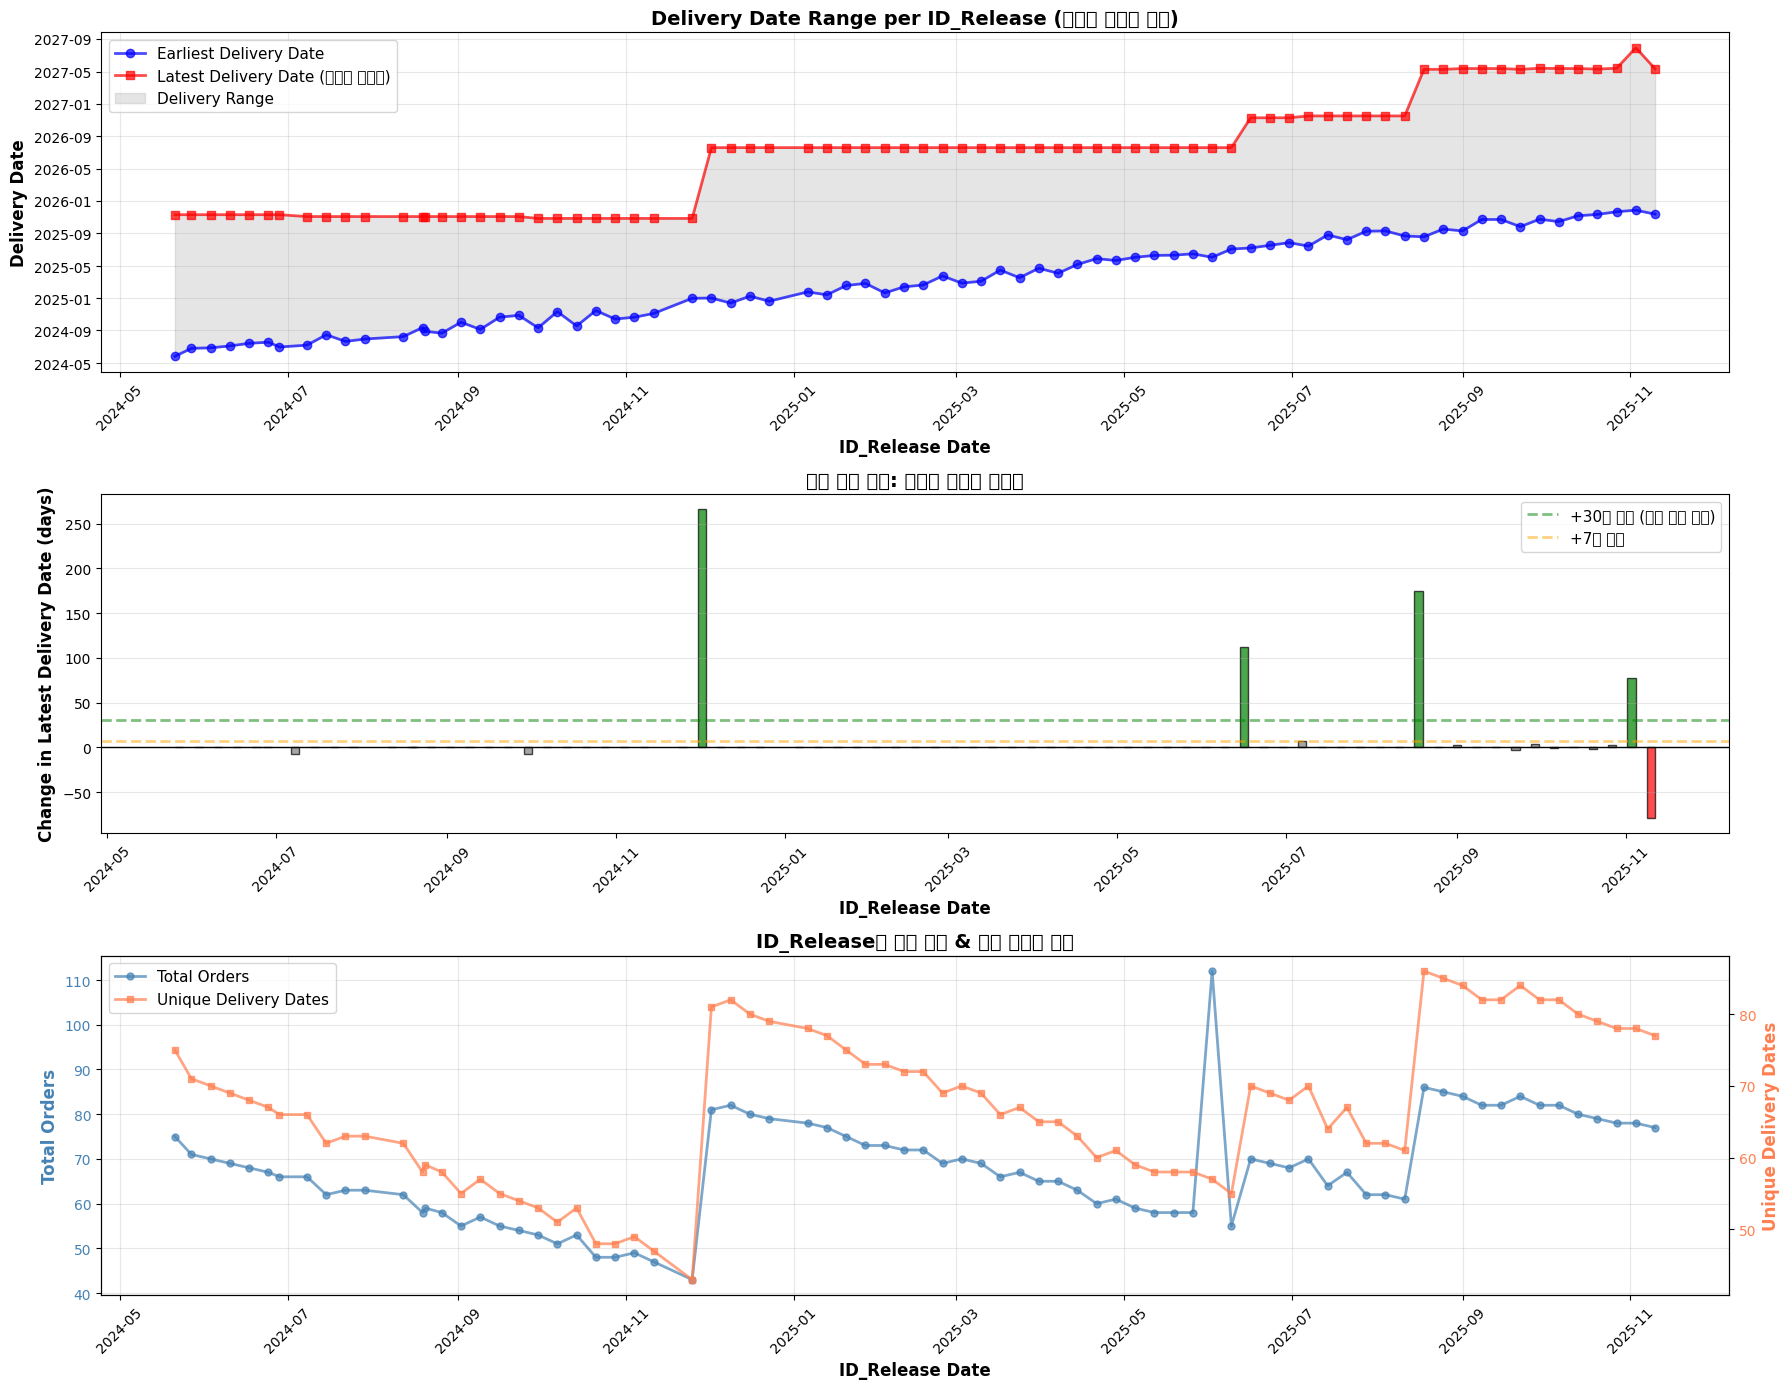

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


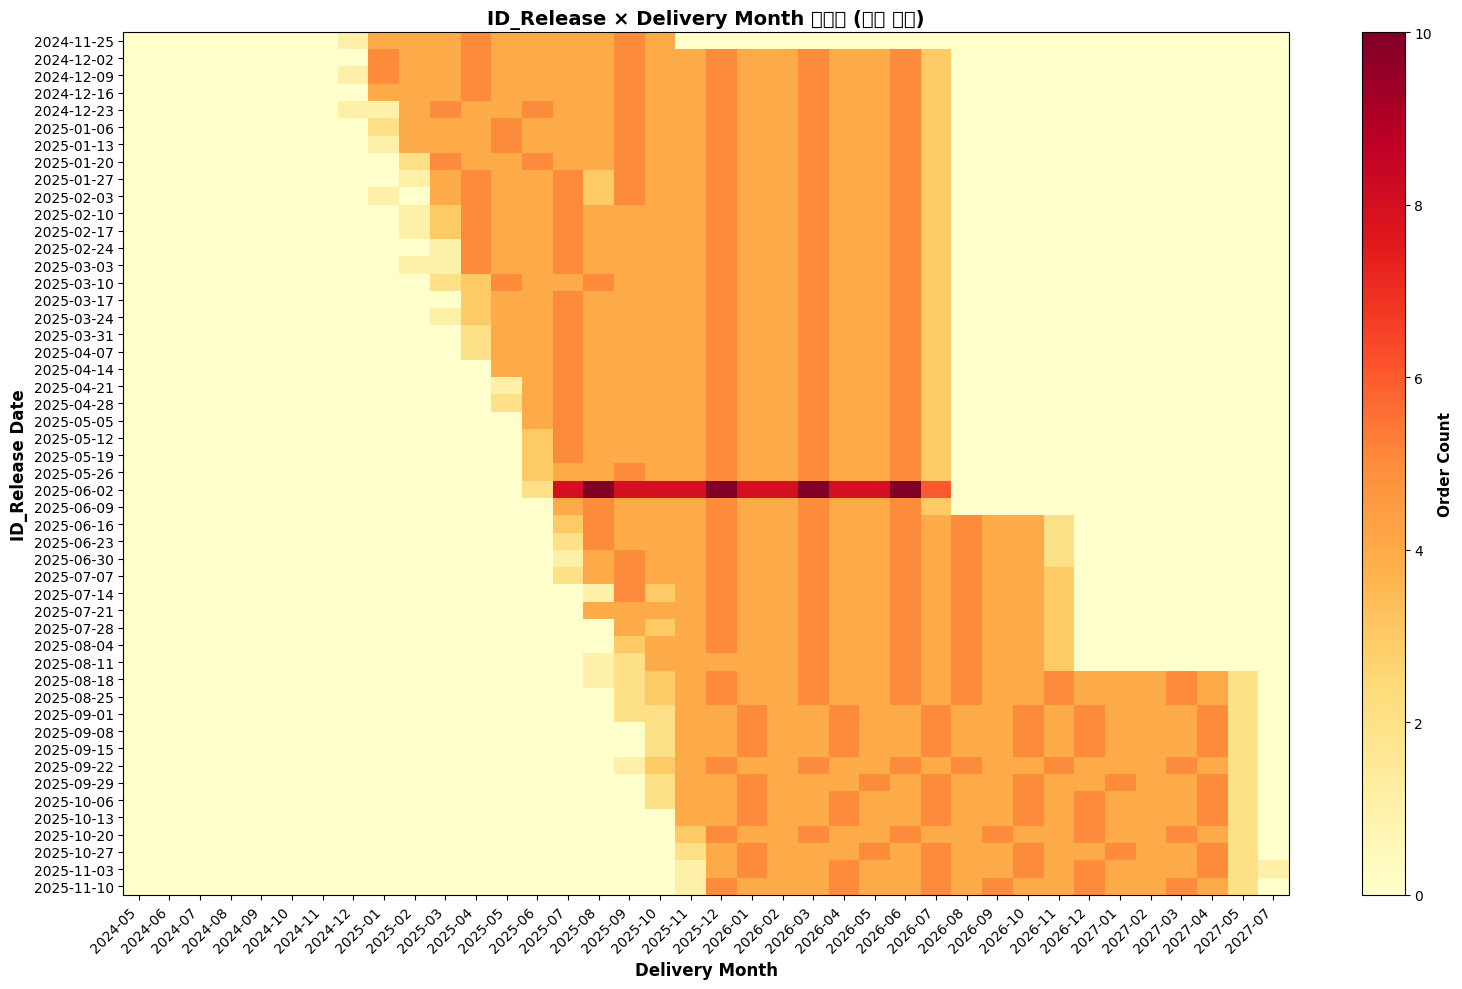

In [13]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A0049000_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)

A0030814X

각 ID_Release별 마지막 납품일 추적 분석

총 76개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     76.000000       76.000000   76.000000              76.000000   
mean      29.184211       28.421053    0.763158              28.986842   
std       15.759620       15.727906    0.780913              15.767049   
min        2.000000        1.000000    0.000000               2.000000   
25%       15.500000       14.000000    0.000000              15.500000   
50%       30.500000       30.000000    1.000000              29.000000   
75%       43.250000       43.000000    1.000000              43.250000   
max       56.000000       54.000000    4.000000              56.000000   

       delivery_range_days  
count            76.000000  
mean            231.973684  
std             113.190338  
min               8.000000  
25%             136.750000  
50%             240.500000  
75%             322.000000  
max             441.000000  


/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 1건

[신규 주문 유입 이벤트]

ID_Release: 2024-10-07
  마지막 납품일 변화: +147일
  새 마지막 납품일: 2025-11-06
  전체 주문: 47건 (FORECAST: 47, FIRM: 0)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 1건

[주문 감소 이벤트]

ID_Release: 2024-09-30
  마지막 납품일 변화: -46일
  새 마지막 납품일: 2025-06-12
  전체 주문: 5건
  → 장기 주문 취소 또는 완료 가능성

ID_Release × 납품일 히트맵 생성


/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1878049418.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.ti


분석 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) m

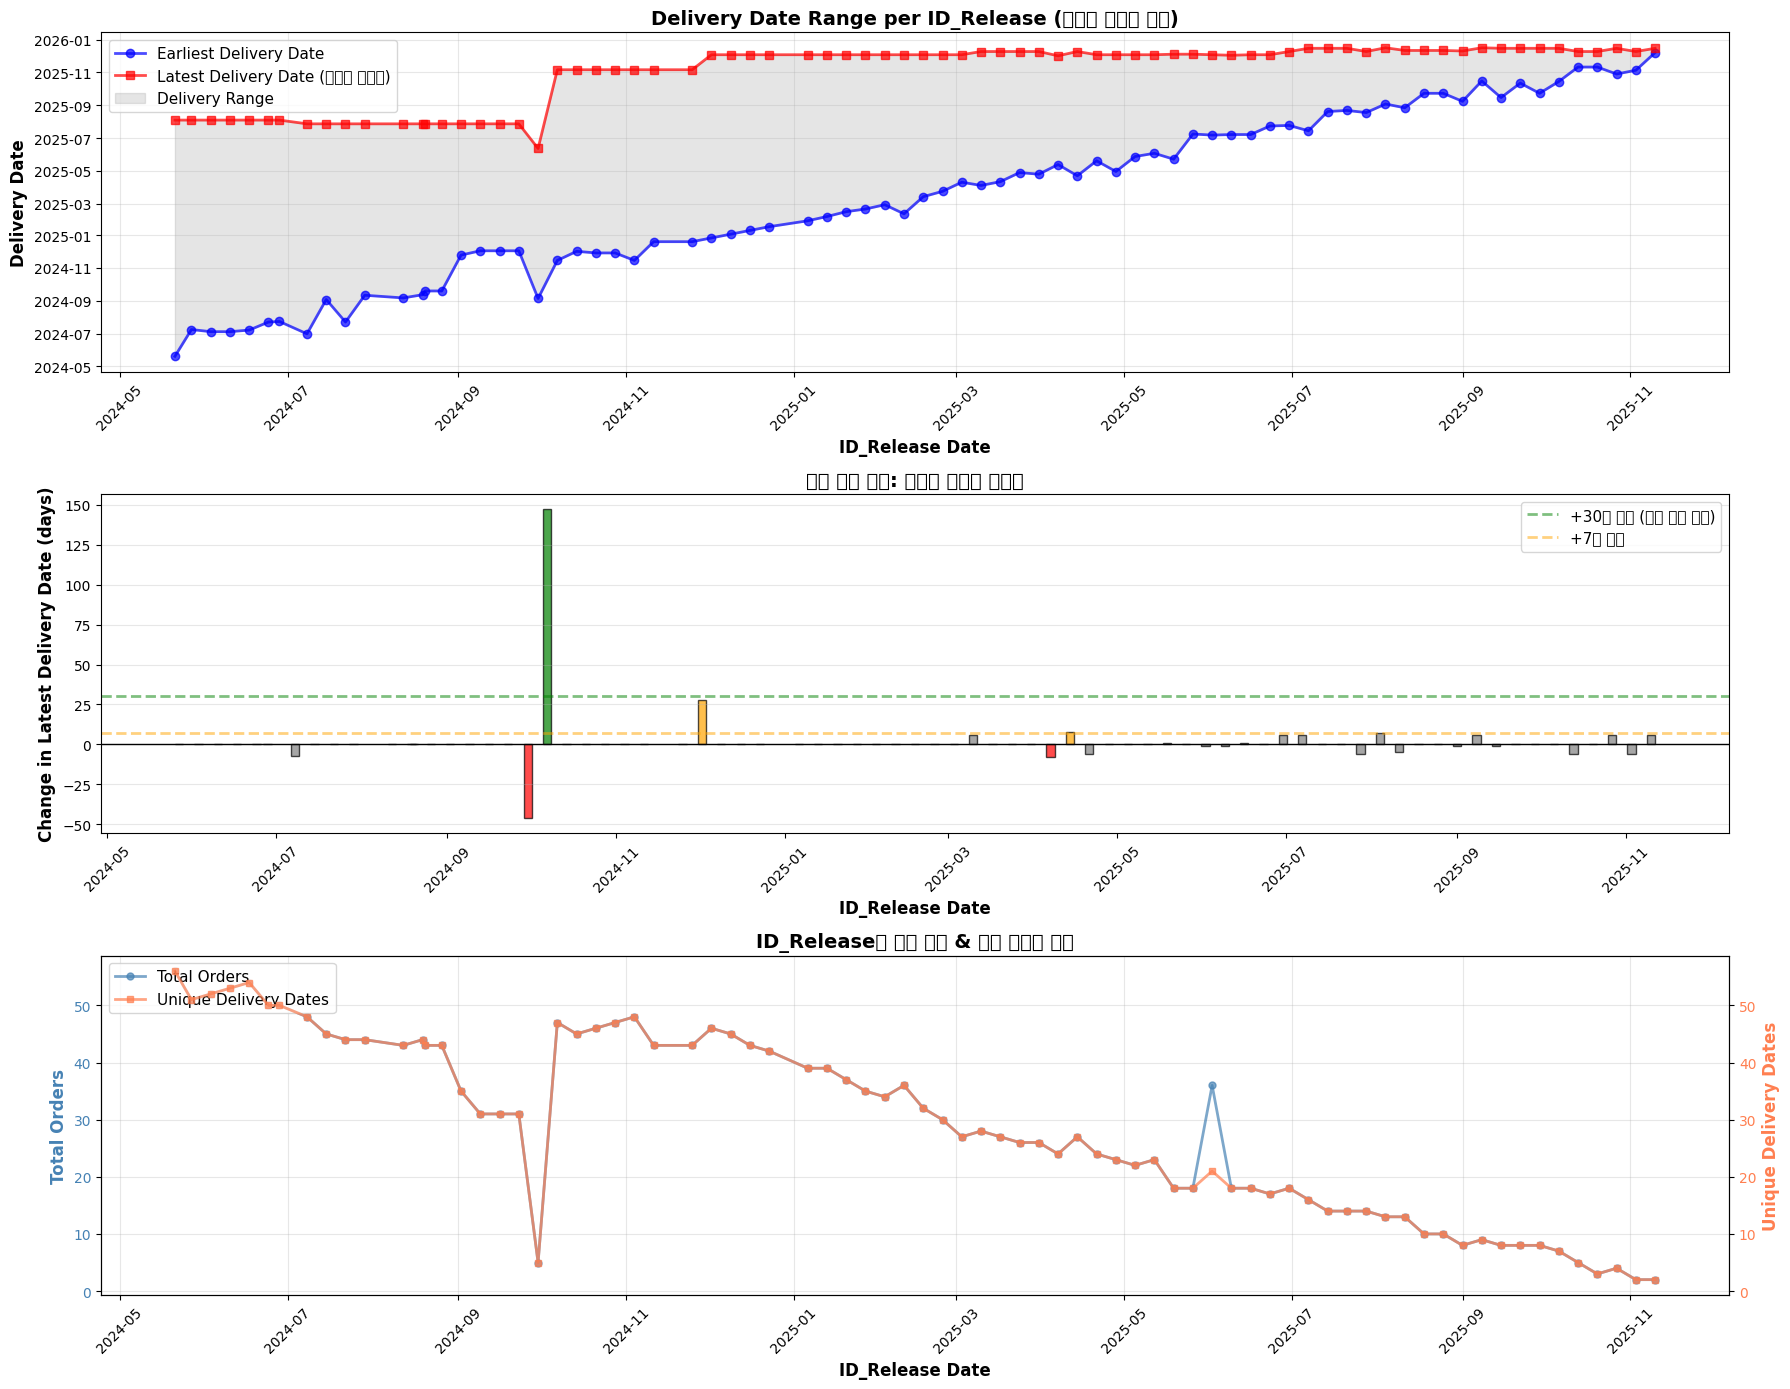

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


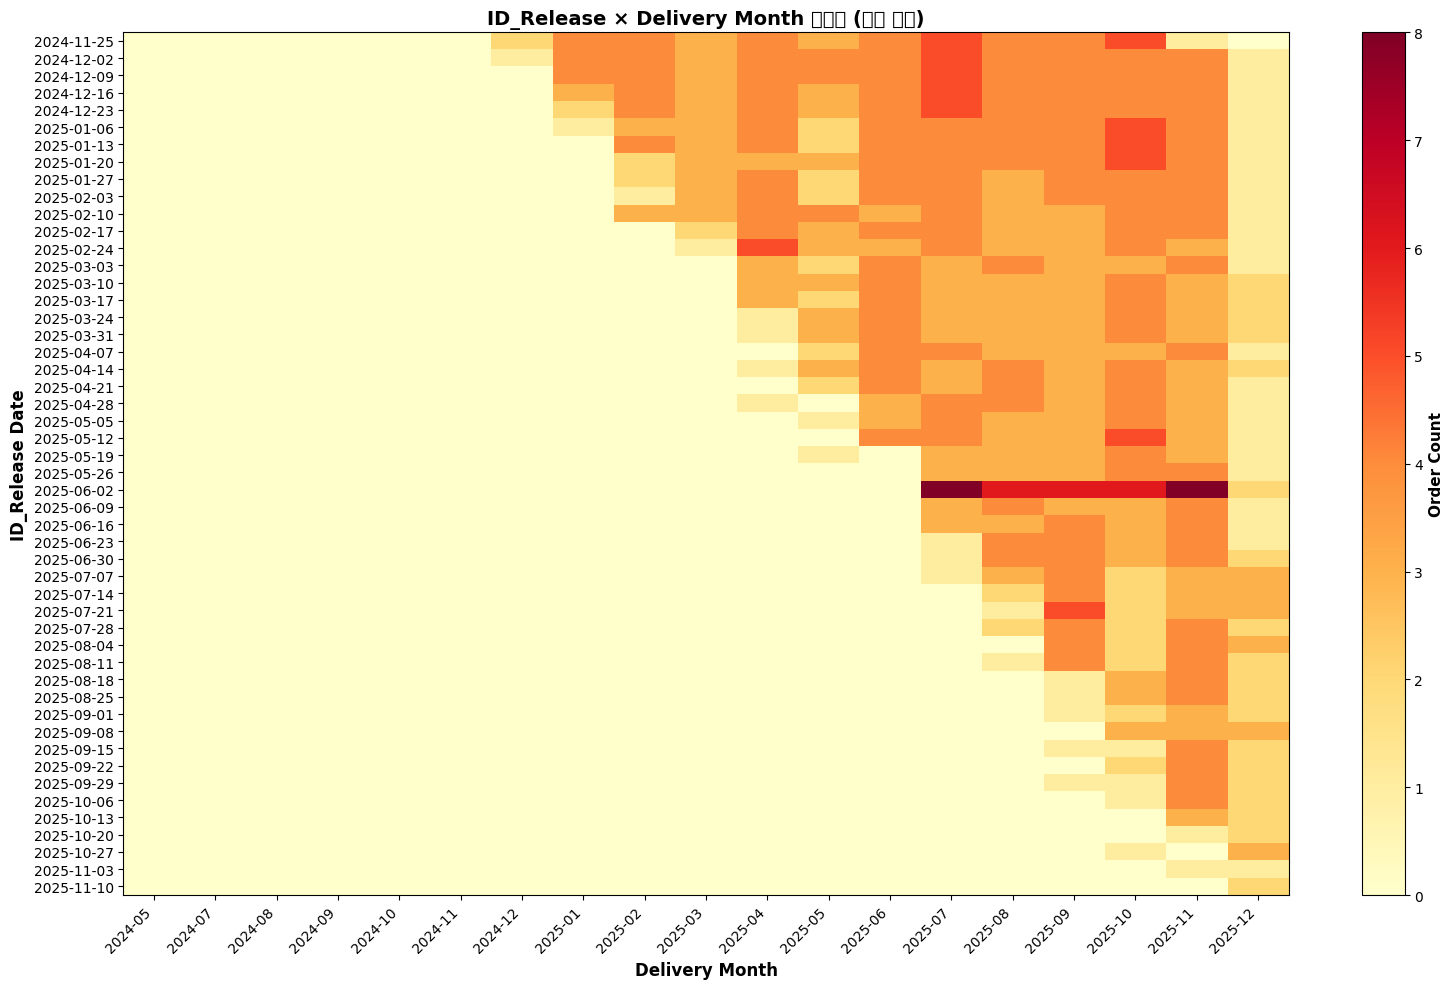

In [12]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A0030814X_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)

A021N565

각 ID_Release별 마지막 납품일 추적 분석

총 76개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     76.000000       76.000000   76.000000              76.000000   
mean      59.276316       58.447368    0.828947              58.447368   
std       18.045571       17.833597    1.011773              16.042772   
min        4.000000        4.000000    0.000000               4.000000   
25%       47.750000       46.000000    0.000000              47.750000   
50%       54.500000       52.000000    1.000000              54.500000   
75%       75.250000       75.250000    1.000000              75.000000   
max      131.000000      126.000000    5.000000              87.000000   

       delivery_range_days  
count            76.000000  
mean            427.157895  
std             118.633897  
min              22.000000  
25%             341.000000  
50%             422.000000  
75%             542.000000  
max             627.000000  


/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 3건

[신규 주문 유입 이벤트]

ID_Release: 2024-10-07
  마지막 납품일 변화: +248일
  새 마지막 납품일: 2025-11-10
  전체 주문: 52건 (FORECAST: 52, FIRM: 0)
  → 신규 장기 주문 유입 가능성

ID_Release: 2024-12-02
  마지막 납품일 변화: +252일
  새 마지막 납품일: 2026-07-20
  전체 주문: 82건 (FORECAST: 81, FIRM: 1)
  → 신규 장기 주문 유입 가능성

ID_Release: 2025-01-06
  마지막 납품일 변화: +84일
  새 마지막 납품일: 2026-10-12
  전체 주문: 87건 (FORECAST: 86, FIRM: 1)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 1건

[주문 감소 이벤트]

ID_Release: 2024-09-30
  마지막 납품일 변화: -143일
  새 마지막 납품일: 2025-03-07
  전체 주문: 4건
  → 장기 주문 취소 또는 완료 가능성

ID_Release × 납품일 히트맵 생성


/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/1526693198.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.ti


분석 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) m

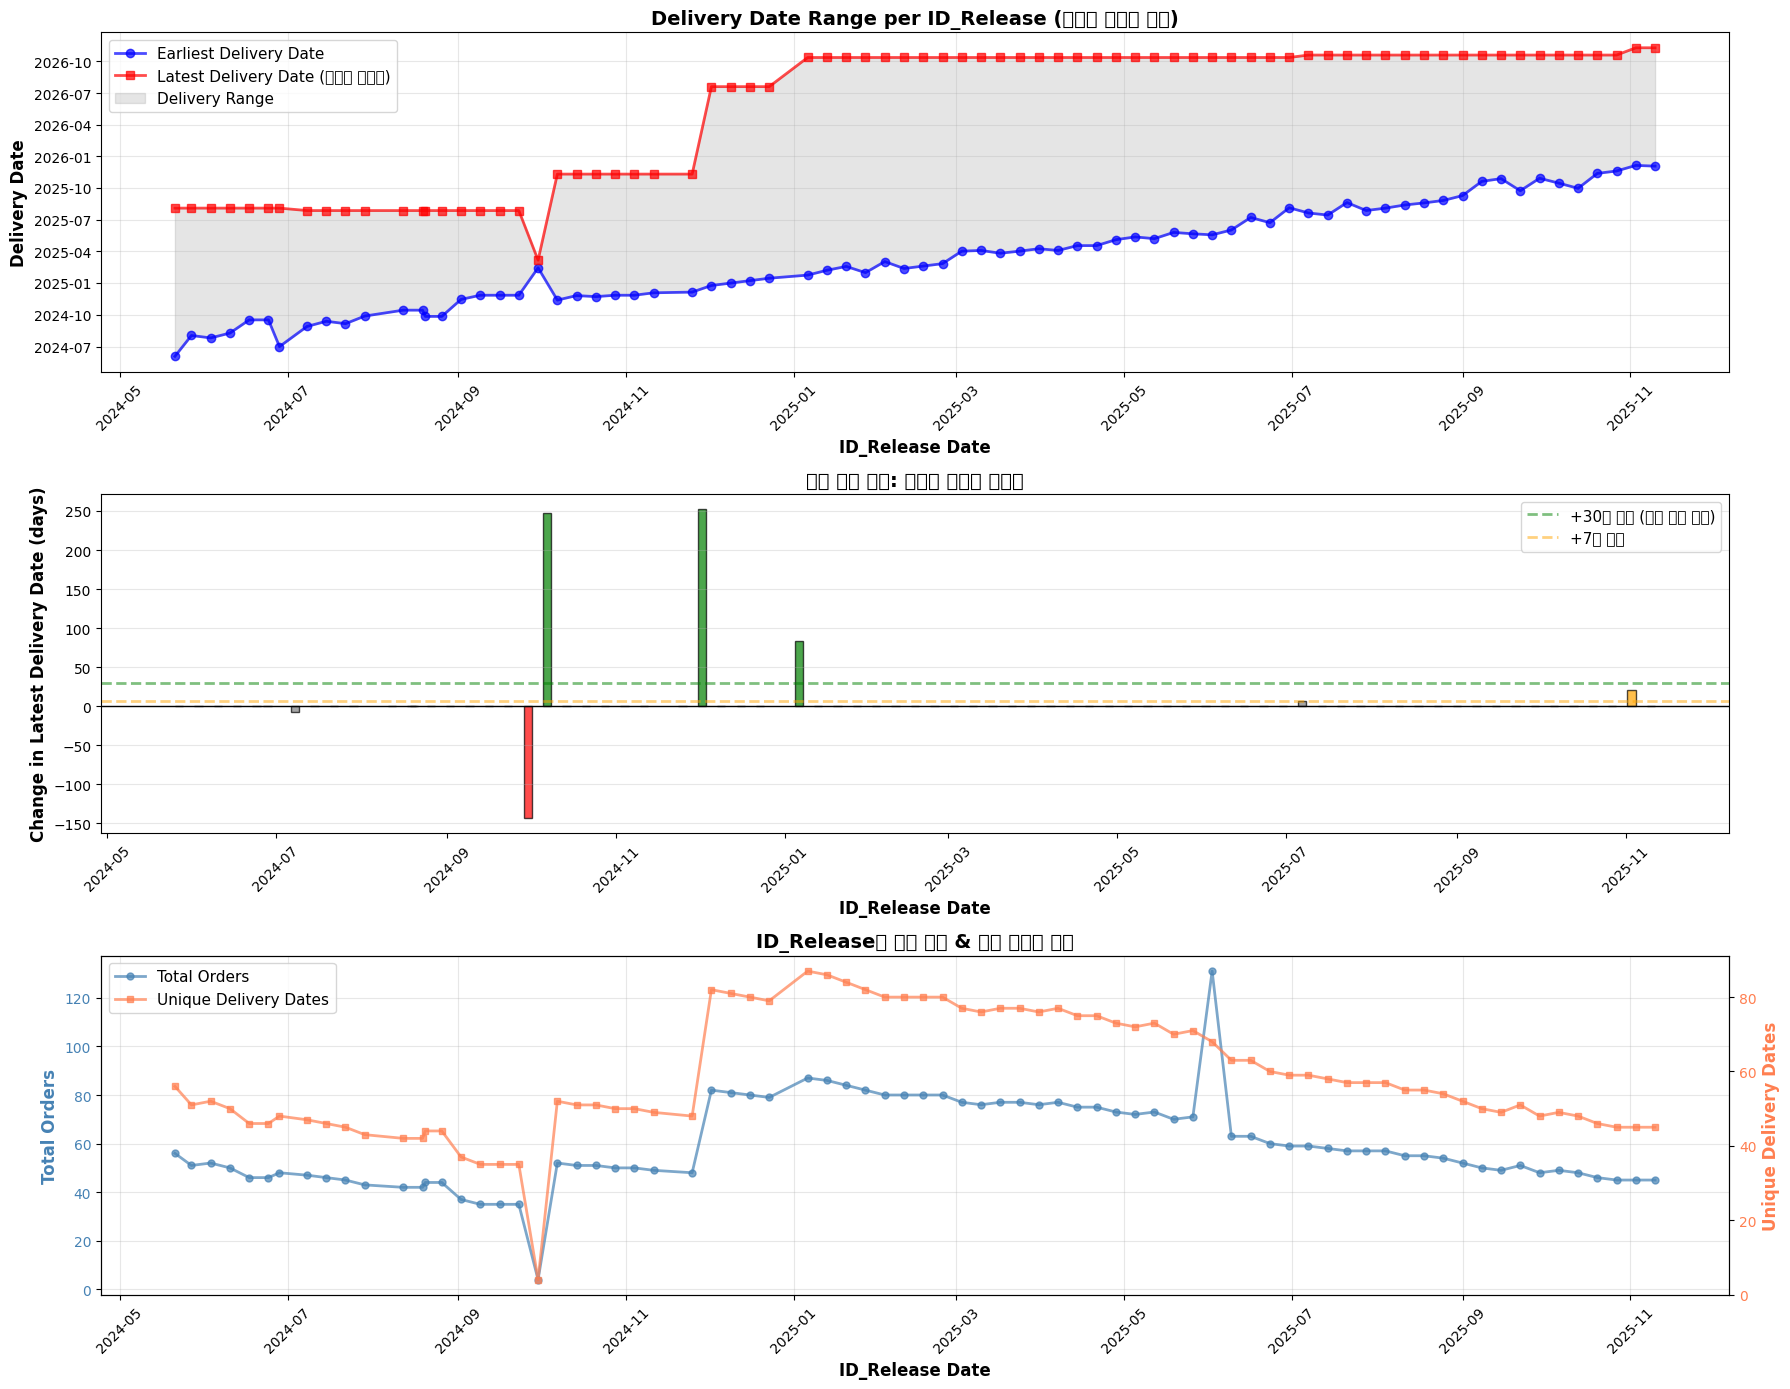

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


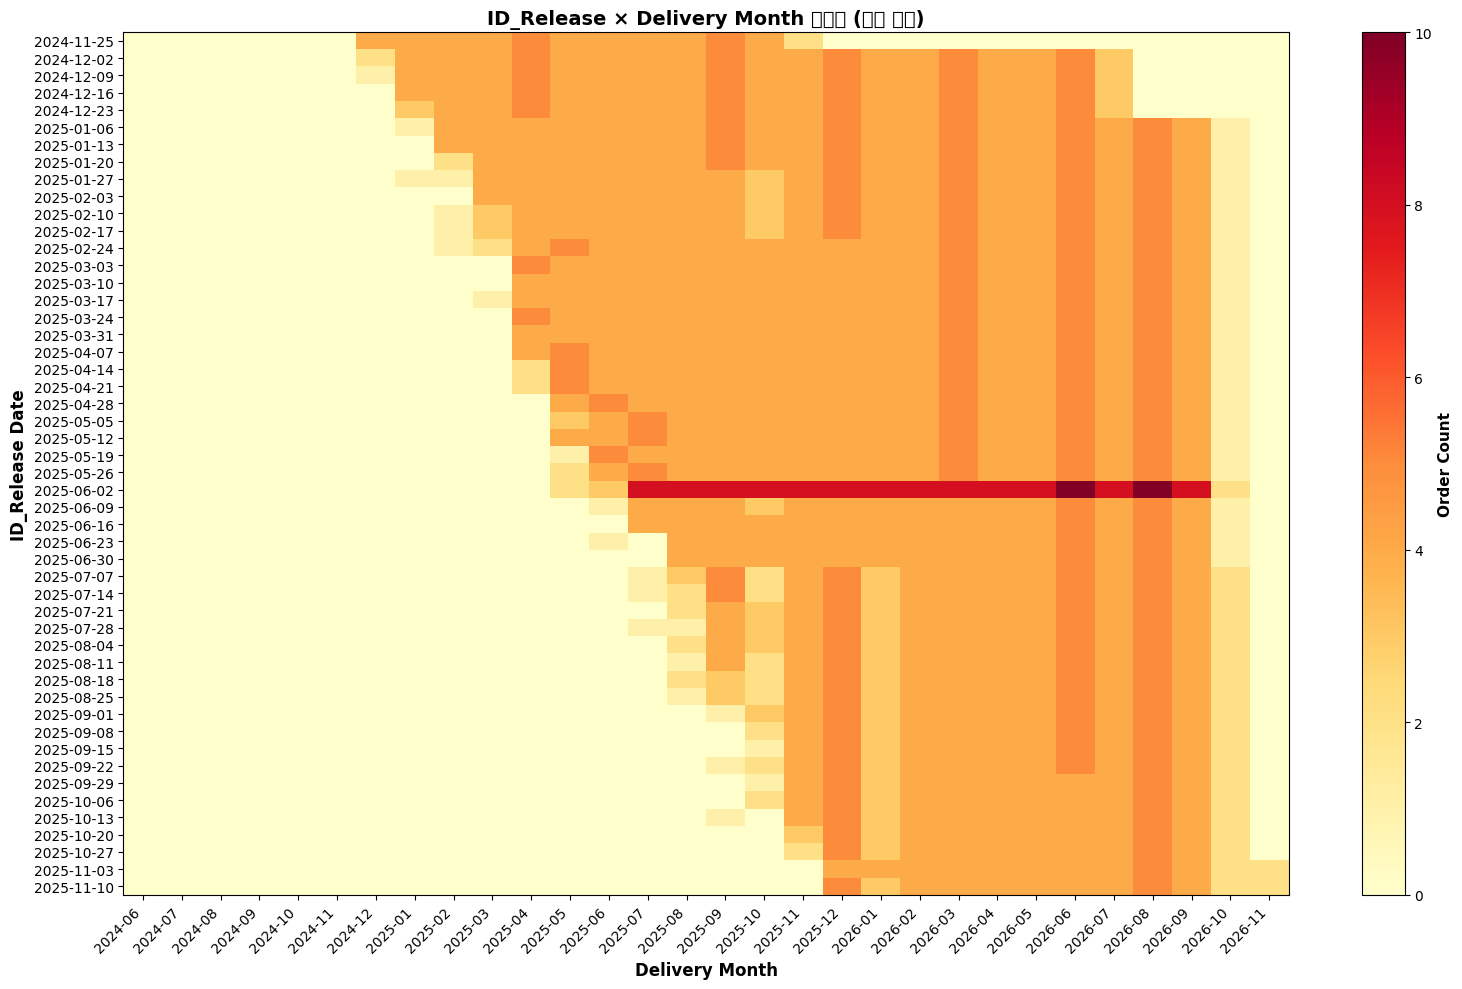

In [14]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A021N565_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)

A0070270

각 ID_Release별 마지막 납품일 추적 분석

총 76개 ID_Release 분석

[기본 통계]
       total_orders  forecast_count  firm_count  unique_delivery_dates  \
count     76.000000       76.000000   76.000000              76.000000   
mean      76.881579       76.065789    0.815789              76.184211   
std       18.532111       18.329819    1.016012              17.188144   
min        2.000000        1.000000    0.000000               2.000000   
25%       65.750000       65.750000    0.000000              65.750000   
50%       80.500000       79.000000    0.000000              80.500000   
75%       89.000000       88.000000    1.000000              89.000000   
max      137.000000      137.000000    4.000000              93.000000   

       delivery_range_days  
count            76.000000  
mean            546.328947  
std             122.508709  
min              32.000000  
25%             466.000000  
50%             595.000000  
75%             645.250000  
max             674.000000  


/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 45225 (\N{HANGUL SYLLABLE NAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:148: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tigh


신규 주문 유입 이벤트 탐지

신규 주문 유입 감지: 1건

[신규 주문 유입 이벤트]

ID_Release: 2025-09-01
  마지막 납품일 변화: +35일
  새 마지막 납품일: 2026-11-25
  전체 주문: 59건 (FORECAST: 59, FIRM: 0)
  → 신규 장기 주문 유입 가능성

주문 취소/완료 의심: 2건

[주문 감소 이벤트]

ID_Release: 2025-11-03
  마지막 납품일 변화: -281일
  새 마지막 납품일: 2026-02-17
  전체 주문: 12건
  → 장기 주문 취소 또는 완료 가능성

ID_Release: 2025-11-10
  마지막 납품일 변화: -67일
  새 마지막 납품일: 2025-12-12
  전체 주문: 2건
  → 장기 주문 취소 또는 완료 가능성

ID_Release × 납품일 히트맵 생성


/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9333/3872868697.py:221: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.ti


분석 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) m

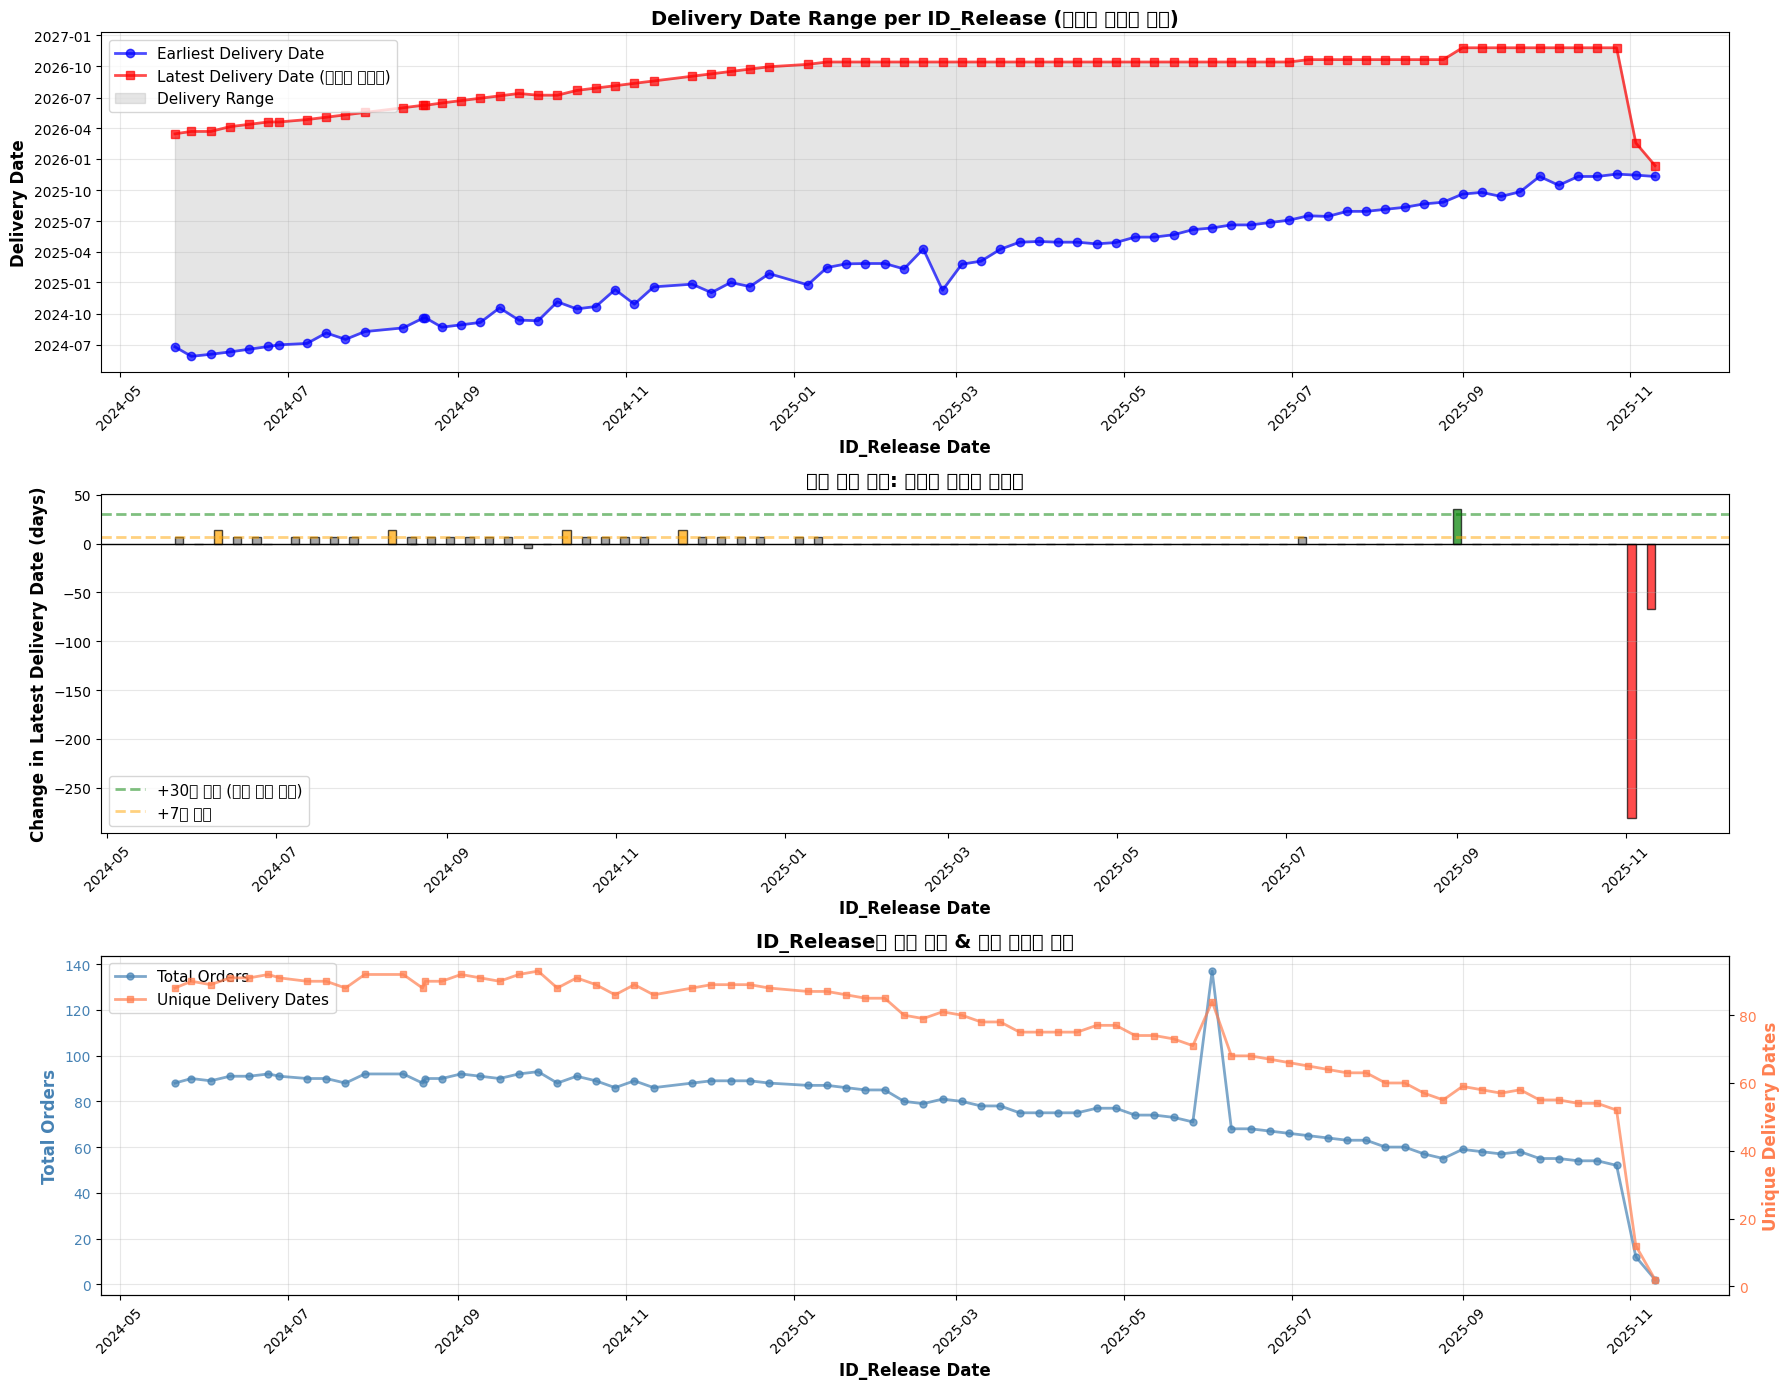

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


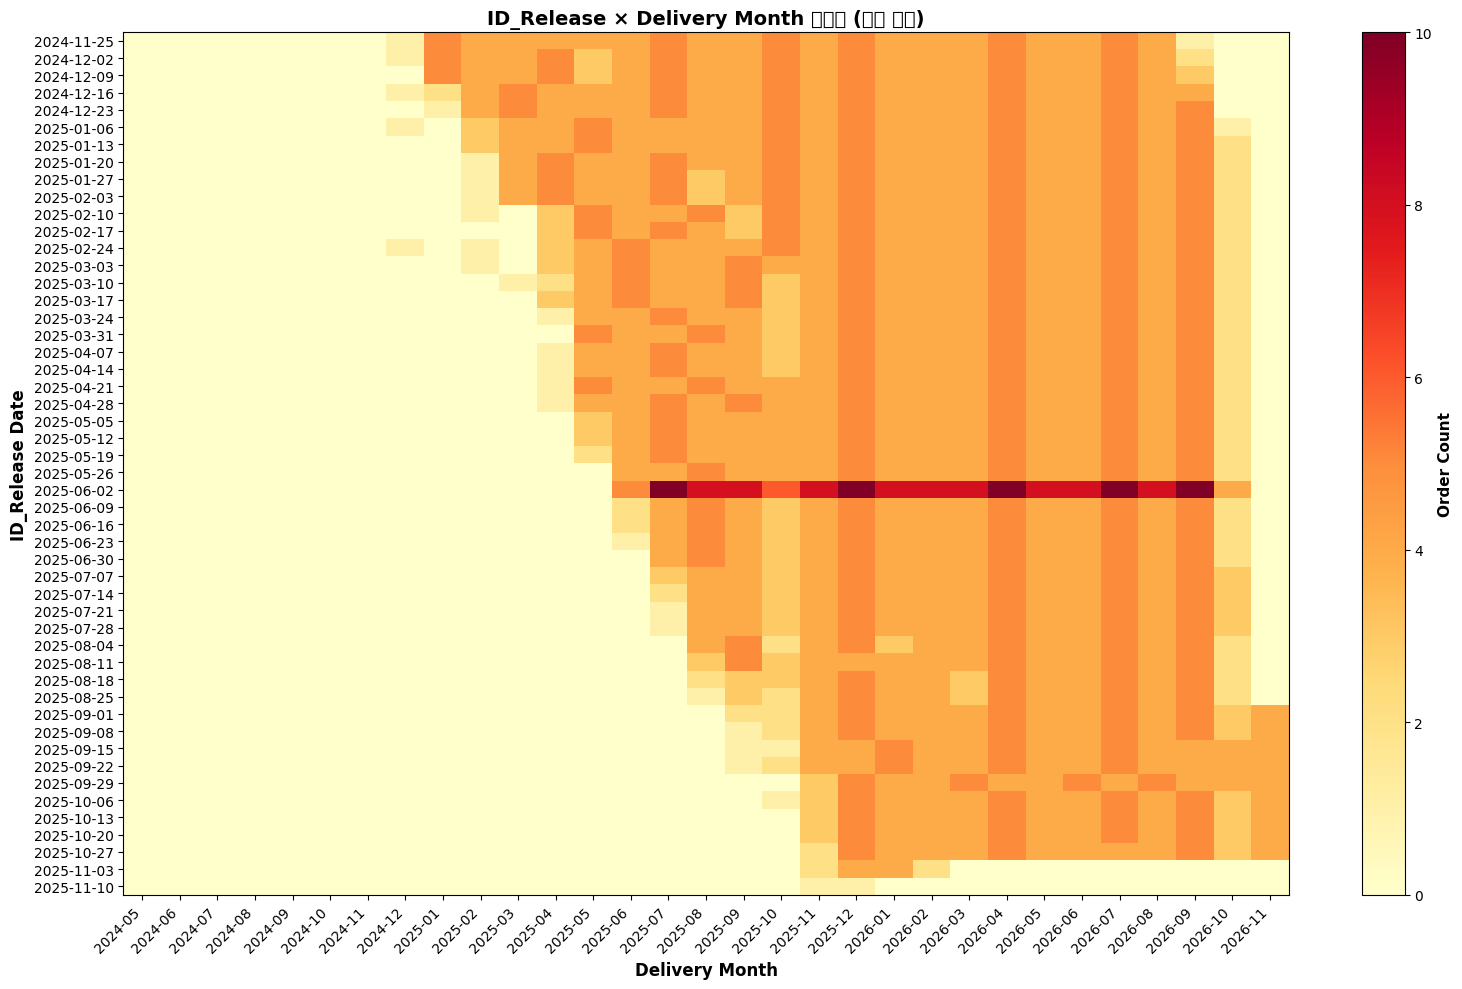

In [15]:
# 갑작스러운 신주문 들어오는 거 확인!!

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# 데이터 읽기
df = pd.read_excel('/content/A0070270_최신데이터.xlsx')

print("="*80)
print("각 ID_Release별 마지막 납품일 추적 분석")
print("="*80)

# 날짜 변환
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df['Delivery_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Day'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

df = df.sort_values('Release_Date').reset_index(drop=True)

# ============================================================================
# 각 ID_Release별 통계
# ============================================================================
release_stats = []

for release_date, group in df.groupby('Release_Date'):
    forecast_group = group[group['Firm/Forecast'] == 'FORECAST']
    firm_group = group[group['Firm/Forecast'] == 'FIRM']

    # 납품일이 있는 것만
    valid_deliveries = group[group['Delivery_Date'].notna()]

    if len(valid_deliveries) > 0:
        stats = {
            'release_date': release_date,
            'total_orders': len(group),
            'forecast_count': len(forecast_group),
            'firm_count': len(firm_group),
            'min_delivery': valid_deliveries['Delivery_Date'].min(),
            'max_delivery': valid_deliveries['Delivery_Date'].max(),
            'delivery_range_days': (valid_deliveries['Delivery_Date'].max() -
                                   valid_deliveries['Delivery_Date'].min()).days,
            'unique_delivery_dates': valid_deliveries['Delivery_Date'].nunique(),
        }
        release_stats.append(stats)

stats_df = pd.DataFrame(release_stats)

print(f"\n총 {len(stats_df)}개 ID_Release 분석")
print(f"\n[기본 통계]")
print(stats_df[['total_orders', 'forecast_count', 'firm_count',
                'unique_delivery_dates', 'delivery_range_days']].describe())

# ============================================================================
# 시각화 1: 마지막 납품일 추적
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# 1-1: 최소 & 최대 납품일 추이
ax = axes[0]
ax.plot(stats_df['release_date'], stats_df['min_delivery'],
       marker='o', color='blue', linewidth=2, markersize=6,
       label='Earliest Delivery Date', alpha=0.7)
ax.plot(stats_df['release_date'], stats_df['max_delivery'],
       marker='s', color='red', linewidth=2, markersize=6,
       label='Latest Delivery Date (마지막 납품일)', alpha=0.7)

# 영역 채우기
ax.fill_between(stats_df['release_date'],
               stats_df['min_delivery'],
               stats_df['max_delivery'],
               alpha=0.2, color='gray', label='Delivery Range')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Date', fontsize=12, fontweight='bold')
ax.set_title('Delivery Date Range per ID_Release (마지막 납품일 추적)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 1-2: 마지막 납품일의 변화량 (신규 주문 탐지)
ax = axes[1]

# 이전 릴리스 대비 마지막 납품일 변화
stats_df['max_delivery_shift'] = stats_df['max_delivery'].diff().dt.days

# 변화량 플롯
colors = ['green' if x > 30 else 'orange' if x > 7 else 'gray' if x >= -7 else 'red'
          for x in stats_df['max_delivery_shift'].fillna(0)]

ax.bar(stats_df['release_date'], stats_df['max_delivery_shift'],
      color=colors, edgecolor='black', alpha=0.7, width=3)

# 기준선
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=30, color='green', linestyle='--', linewidth=2,
          alpha=0.5, label='+30일 이상 (신규 주문 유입)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=2,
          alpha=0.5, label='+7일 이상')

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Change in Latest Delivery Date (days)', fontsize=12, fontweight='bold')
ax.set_title('신규 주문 탐지: 마지막 납품일 변화량',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

# 1-3: 주문 건수 & 고유 납품일 개수
ax = axes[2]

ax2 = ax.twinx()

# 주문 건수
line1 = ax.plot(stats_df['release_date'], stats_df['total_orders'],
               marker='o', color='steelblue', linewidth=2, markersize=5,
               label='Total Orders', alpha=0.7)

# 고유 납품일 개수
line2 = ax2.plot(stats_df['release_date'], stats_df['unique_delivery_dates'],
                marker='s', color='coral', linewidth=2, markersize=5,
                label='Unique Delivery Dates', alpha=0.7)

ax.set_xlabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Orders', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('Unique Delivery Dates', fontsize=12, fontweight='bold', color='coral')
ax.set_title('ID_Release별 주문 건수 & 고유 납품일 개수',
            fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')
ax.tick_params(axis='x', rotation=45)

# 범례 합치기
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=11, loc='upper left')

ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================================
# 신규 주문 유입 이벤트 탐지
# ============================================================================
print("\n" + "="*80)
print("신규 주문 유입 이벤트 탐지")
print("="*80)

# 마지막 납품일이 30일 이상 늘어난 케이스
new_order_events = stats_df[stats_df['max_delivery_shift'] > 30].copy()

print(f"\n신규 주문 유입 감지: {len(new_order_events)}건")

if len(new_order_events) > 0:
    print("\n[신규 주문 유입 이벤트]")
    for idx, event in new_order_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: +{event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건 (FORECAST: {event['forecast_count']}, FIRM: {event['firm_count']})")
        print(f"  → 신규 장기 주문 유입 가능성")

# 마지막 납품일이 크게 줄어든 케이스 (주문 취소/완료?)
cancelled_events = stats_df[stats_df['max_delivery_shift'] < -30].copy()

print(f"\n주문 취소/완료 의심: {len(cancelled_events)}건")

if len(cancelled_events) > 0:
    print("\n[주문 감소 이벤트]")
    for idx, event in cancelled_events.iterrows():
        print(f"\nID_Release: {event['release_date'].date()}")
        print(f"  마지막 납품일 변화: {event['max_delivery_shift']:.0f}일")
        print(f"  새 마지막 납품일: {event['max_delivery'].date()}")
        print(f"  전체 주문: {event['total_orders']}건")
        print(f"  → 장기 주문 취소 또는 완료 가능성")

# ============================================================================
# 시각화 2: 납품일 분포 히트맵
# ============================================================================
print("\n" + "="*80)
print("ID_Release × 납품일 히트맵 생성")
print("="*80)

# 각 릴리스별 납품 월 분포
df['Delivery_Month'] = df['Delivery_Date'].dt.to_period('M')

pivot_data = df.groupby(['Release_Date', 'Delivery_Month']).size().unstack(fill_value=0)

# 상위 릴리스만 (너무 많으면 보기 어려움)
if len(pivot_data) > 50:
    pivot_data = pivot_data.iloc[-50:]  # 최근 50개만

fig, ax = plt.subplots(figsize=(16, 10))

# 히트맵
im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# 축 설정
ax.set_xticks(np.arange(len(pivot_data.columns)))
ax.set_yticks(np.arange(len(pivot_data.index)))
ax.set_xticklabels([str(x) for x in pivot_data.columns], rotation=45, ha='right')
ax.set_yticklabels([x.strftime('%Y-%m-%d') for x in pivot_data.index])

ax.set_xlabel('Delivery Month', fontsize=12, fontweight='bold')
ax.set_ylabel('ID_Release Date', fontsize=12, fontweight='bold')
ax.set_title('ID_Release × Delivery Month 히트맵 (주문 분포)',
            fontsize=14, fontweight='bold')

# 컬러바
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Order Count', fontsize=11, fontweight='bold')

plt.tight_layout()


print("\n" + "="*80)
print("분석 완료!")
print("="*80)